<a href="https://colab.research.google.com/github/yangjinn2050/uranium_1/blob/main/handson_03_MLIP_%EB%82%A8%EC%A7%80%EC%9B%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pre-Installations

## Get GPAW for DFT calculation

In [2]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!pip install tqdm

In [3]:
!apt-get update -y
!apt-get install -y openmpi-bin libopenmpi-dev build-essential
!git clone -b 25.7.0 https://gitlab.com/gpaw/gpaw.git
%cd gpaw
!pip install numpy scipy ase mpi4py
!pip install .
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
!python -m gpaw install-data --version=24.11.0 --register /content/gpaw-setups
!python -m gpaw info

# Import ASE and GPAW and run your calculation
from ase import Atoms
from gpaw import GPAW

# Define the atomic structure
d = 0.74
a = 10.0

h2 = Atoms('H2',
              positions=[(0, 0, 0),
                         (0, 0, d)],
              cell=(a, a, a))
h2.center()
# Initialize GPAW calculator without specifying the 'setups' parameter
calc = GPAW(mode='fd', nbands=2, txt='h2.txt')
h2.calc = calc

# Run the calculation
print("Forces on atoms:", h2.get_forces())
print("Energies on atoms:", h2.get_total_energy())

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [90.8 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-povray libboost-thread1.74.0 libilmbase25 libopenexr25 libsdl1.2debian
  povray-includes
Suggested packages:
  povray-doc povray-examples
The following NEW packages will be installed:
  fonts-povray libboost-thread1.74.0 libilmbase25 libopenexr25 libsdl1.2debian
  povray povray-includes
0 upgraded, 7 newly installed, 0 to remove and 127 not upgraded.
Need to get 3,010 kB of archives.
After this operation, 11.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-povray all 1:3.7.0.10-1 [70.0 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-thread1.74.0 amd64 1.74.0-14ubuntu3 [262 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libilmbase25 amd64 2.5.7-2 [175 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenexr25 amd64 2

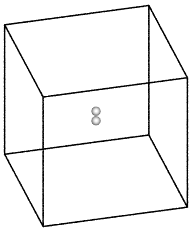

In [4]:
!sudo apt-get install povray  ## visulization program

import shutil
from ase.io import write  # Import the write function from ASE
from PIL import Image
from IPython.display import display  # Import display for Jupyter Notebooks


def visual(structure, max_size=(200, 200), stretch_y=2.0, rotation='15z,-60x', png_save_path='./'):
    renderer = write('./temp.pov', structure, rotation=rotation)
    renderer.render()
    image_path = './temp.png'
    img = Image.open(image_path)
    display(img)

    files = ['./temp.ini', './temp.pov', './temp.png']
    destination = './output/'

    os.makedirs(destination, exist_ok=True)

    for file in files:
        if os.path.isfile(os.path.join(destination, os.path.basename(file))):
            os.remove(os.path.join(destination, os.path.basename(file)))

        if file == './temp.png':
            new_file_name = png_save_path + f'temp.png'
        else:
            new_file_name = os.path.basename(file)
        shutil.move(file, os.path.join(destination, new_file_name))
visual(h2)

def enlarge_and_visual(atoms,angle='15z,-60x'):
  temp=atoms.copy()
  temp=temp*(3,3,1)
  temp.cell=atoms.cell
  visual(temp, rotation=angle)

## Get MACE for MLIP calculation

- Github from https://github.com/ACEsuit/mace

In [6]:
!pip install --upgrade pip
!pip install mace-torch
!pip install pymatgen
!pip install ase

# __Excecution comparison : DFT vs MLP__

## Time Scale

In [7]:
!pip install gpaw

In [8]:
## Install povray for visualization
!sudo apt-get install povray

import shutil
from ase.io import write  # Import the write function from ASE
from PIL import Image
from IPython.display import display  # Import display for Jupyter Notebooks


def visual(structure, max_size=(200, 200), stretch_y=2.0, rotation='15z,-60x', png_save_path='./'):
    renderer = write('./temp.pov', structure, rotation=rotation)
    renderer.render()
    image_path = './temp.png'
    img = Image.open(image_path)

    # Calculate new size with stretch factor
    new_size = (max_size[0], int(max_size[1] * stretch_y))
    img = img.resize(new_size, Image.LANCZOS)
    display(img)

    # Move files to output directory
    files = ['./temp.ini', './temp.pov', './temp.png']
    destination = './output/'

    # Ensure destination directory exists
    os.makedirs(destination, exist_ok=True)

    for file in files:
        # Remove the file in the destination directory if it exists
        if os.path.isfile(os.path.join(destination, os.path.basename(file))):
            os.remove(os.path.join(destination, os.path.basename(file)))

        if file == './temp.png':
            new_file_name = png_save_path + f'temp.png'
        else:
            new_file_name = os.path.basename(file)
        shutil.move(file, os.path.join(destination, new_file_name))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
povray is already the newest version (1:3.7.0.10-1).
0 upgraded, 0 newly installed, 0 to remove and 127 not upgraded.


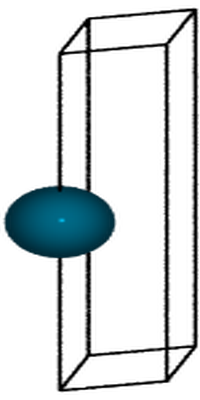

[1 atoms] GPAW execution time: 6.0694 sec


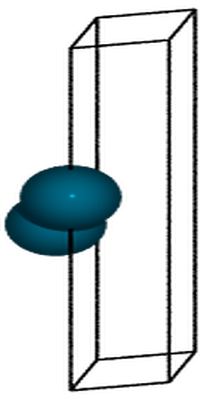

[2 atoms] GPAW execution time: 10.9021 sec


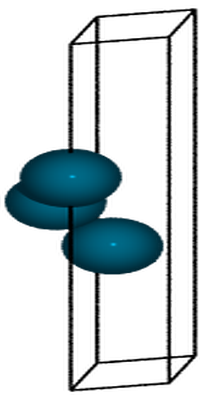

[3 atoms] GPAW execution time: 14.4151 sec


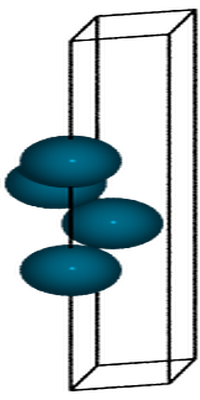

[4 atoms] GPAW execution time: 21.9095 sec


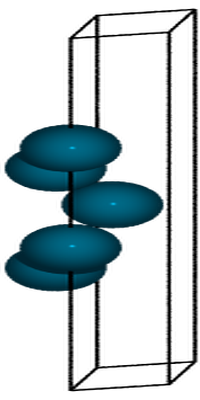

[5 atoms] GPAW execution time: 68.1426 sec


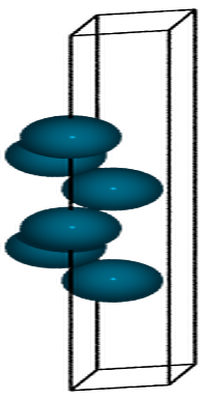

[6 atoms] GPAW execution time: 67.9223 sec


In [10]:
from ase import Atoms
from ase.visualize import view
from gpaw import GPAW, PW
from ase.build import bulk
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ase.build import fcc111
from ase.constraints import FixAtoms
import time

name = 'Pd-fcc' ### TO-DO: Fill your element
a0 = 3.93  # fcc lattice parameter
k = 1
element= 'Pd' ### TO-DO: Fill your element
vac=7.5
size=2

# Set up the GPAW calculator
gpaw_calc = GPAW(mode=PW(400),
            kpts=(k, k, 1),
            xc='PBE',
            txt='slab.txt')

gpaw_elapsed_time_list = []

N_layer_list = [1,2,3,4,5,6]

for N_layer in N_layer_list:
    gpaw_surf = fcc111(element, (1, 1, N_layer), a=a0, vacuum=vac)
    gpaw_surf.calc = gpaw_calc

    median_z = np.median(gpaw_surf.positions[:, 2])
    constraint = FixAtoms(mask=[atom.position[2] < (median_z + 0.01) for atom in gpaw_surf])
    gpaw_surf.set_constraint(constraint)

    # GPAW computation time
    start_time = time.time()
    _ = gpaw_surf.get_potential_energy()
    end_time = time.time()
    visual(gpaw_surf)
    gpaw_elapsed_time = end_time - start_time
    gpaw_elapsed_time_list.append(gpaw_elapsed_time)

    print(f'[{len(gpaw_surf)} atoms] GPAW execution time: {gpaw_elapsed_time:.4f} sec')

TO-DO: set up the same conditions for MACE calculation
- visualize slab & print execution time (in ms scale) for each slab
- get mace_elapsed_time_list

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


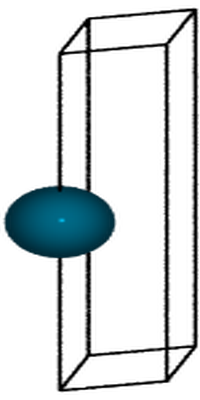

[1 atoms] MACE execution time: 2.0884 sec


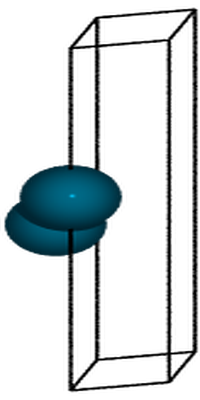

[2 atoms] MACE execution time: 0.3898 sec


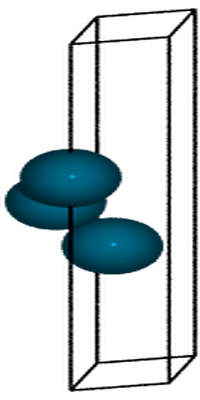

[3 atoms] MACE execution time: 1.4357 sec


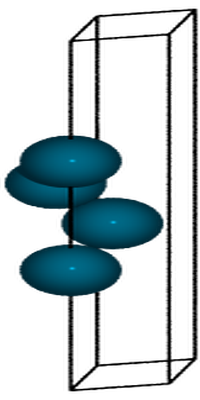

[4 atoms] MACE execution time: 0.8025 sec


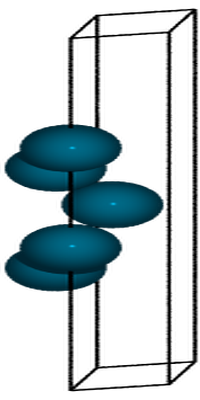

[5 atoms] MACE execution time: 1.0874 sec


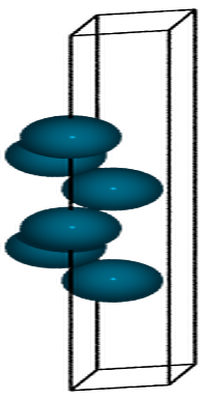

[6 atoms] MACE execution time: 0.0460 sec


In [11]:

from mace.calculators import mace_mp


# Set up the MACE calculator
mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float32", device='cuda')
mace_elapsed_time_list = []

### TO-DO: set up the same conditions for mace_surf
mace_elapsed_time_list = []

N_layer_list = [1,2,3,4,5,6]

for N_layer in N_layer_list:
    mace_surf = fcc111(element, (1, 1, N_layer), a=a0, vacuum=vac)
    mace_surf.calc = mace_calc

    median_z = np.median(mace_surf.positions[:, 2])
    constraint = FixAtoms(mask=[atom.position[2] < (median_z + 0.01) for atom in mace_surf])
    mace_surf.set_constraint(constraint)

        # GPAW computation time
    start_time = time.time()
    _ = mace_surf.get_potential_energy()
    end_time = time.time()
    visual(mace_surf)
    mace_elapsed_time = end_time - start_time
    mace_elapsed_time_list.append(mace_elapsed_time)

    print(f'[{len(mace_surf)} atoms] MACE execution time: {mace_elapsed_time:.4f} sec')

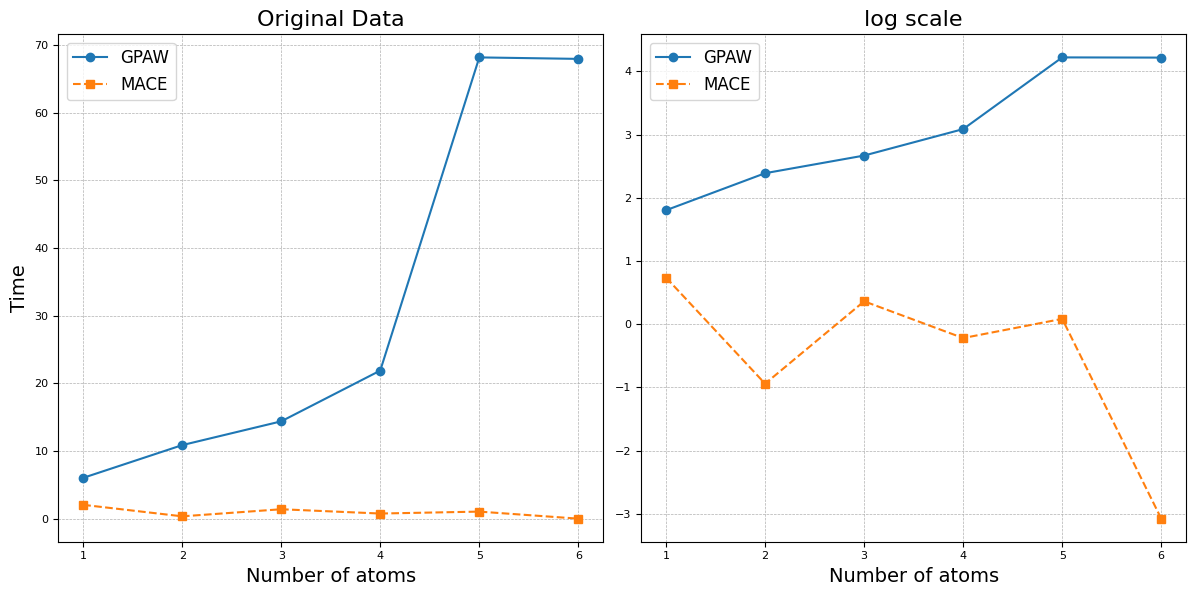

In [12]:
# Execution time plot for GPAW vs MACE comparison
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

x = N_layer_list
y1 = gpaw_elapsed_time_list
y2 = mace_elapsed_time_list
y1_legend = 'GPAW'
y2_legend = 'MACE'

log_y1 = np.log(y1)
log_y2 = np.log(y2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(x, y1, label=y1_legend, marker='o', linestyle='-', markersize=6)
axes[0].plot(x, y2, label=y2_legend, marker='s', linestyle='--', markersize=6)
axes[0].set_title('Original Data', fontsize=16)
axes[0].set_xlabel('Number of atoms', fontsize=14)
axes[0].set_ylabel('Time', fontsize=14)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend(fontsize=12)

axes[1].plot(x, log_y1, label=y1_legend, marker='o', linestyle='-', markersize=6)
axes[1].plot(x, log_y2, label=y2_legend, marker='s', linestyle='--', markersize=6)
axes[1].set_title('log scale', fontsize=16)
axes[1].set_xlabel('Number of atoms', fontsize=14)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

## Size Scale

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


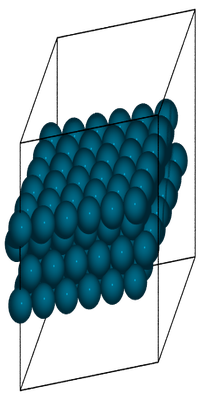

[144 atoms] MACE execution time: 125.8302 ms


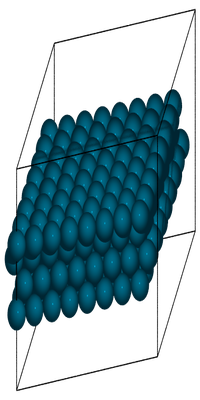

[256 atoms] MACE execution time: 181.6943 ms


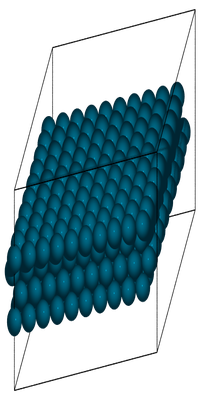

[400 atoms] MACE execution time: 237.2191 ms


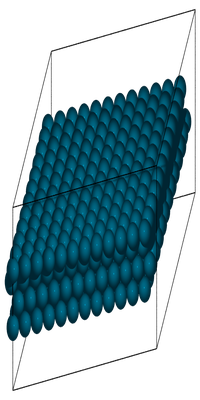

[576 atoms] MACE execution time: 313.5796 ms


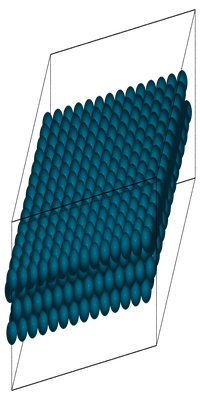

[784 atoms] MACE execution time: 417.0604 ms


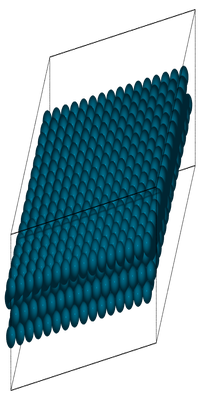

[1024 atoms] MACE execution time: 513.5367 ms


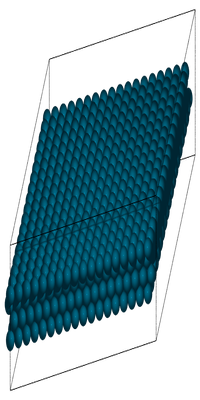

[1296 atoms] MACE execution time: 623.8391 ms


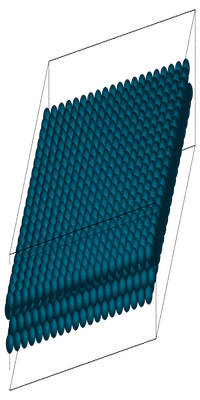

[1600 atoms] MACE execution time: 741.9660 ms


In [13]:
# Surface Energy calculations for larger slab sizes
from mace.calculators import mace_mp

mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float32", device='cuda')
mace_elapsed_time_list_by_size = []
size_up = [6,8,10,12,14,16,18,20]
for size in size_up:
    vac = 7.5
    mace_surf = fcc111(element, (size, size, 4), a=a0, vacuum=vac)
    mace_surf.calc = mace_calc

    # MACE computation time
    start_time = time.time()
    _ = mace_surf.get_potential_energy()
    end_time = time.time()
    visual(mace_surf)

    mace_elapsed_time = end_time - start_time
    mace_elapsed_time_list_by_size.append(mace_elapsed_time)

    print(f'[{len(mace_surf)} atoms] MACE execution time: {mace_elapsed_time * 1000 :.4f} ms')

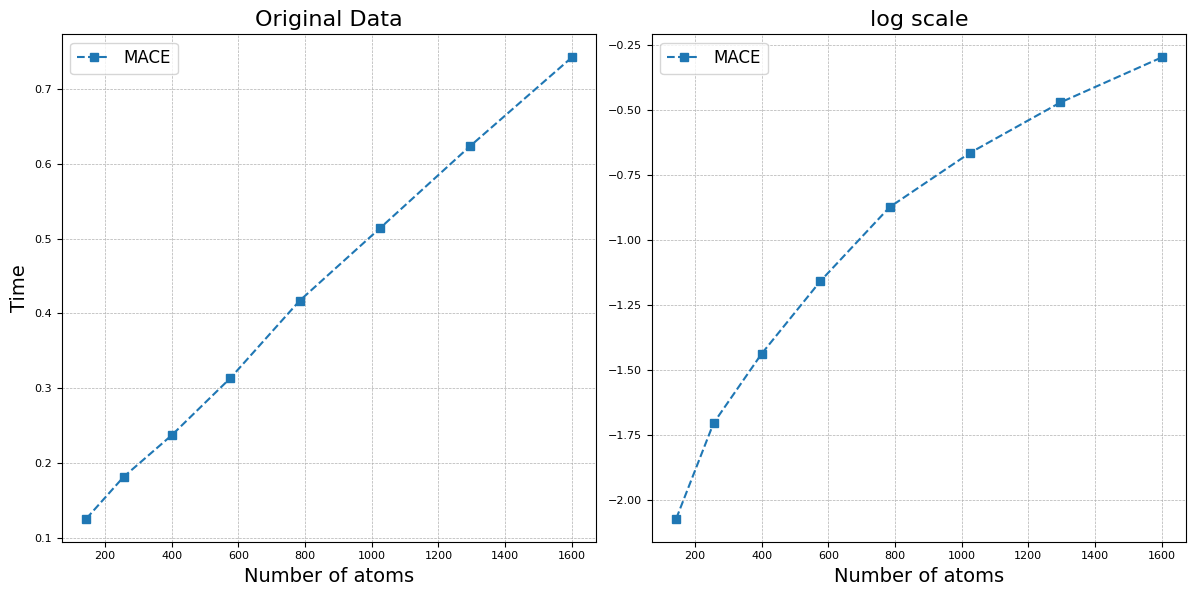

In [15]:
# For visualizing
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

y2 = mace_elapsed_time_list_by_size
y2_legend = 'MACE'

log_y2 = np.log(y2)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
num_list=np.array(size_up)*np.array(size_up)*4
axes[0].plot(num_list, y2, label=y2_legend, marker='s', linestyle='--', markersize=6)
axes[0].set_title('Original Data', fontsize=16)
axes[0].set_xlabel('Number of atoms', fontsize=14)
axes[0].set_ylabel('Time', fontsize=14)
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[0].legend(fontsize=12)

axes[1].plot(num_list, log_y2, label=y2_legend, marker='s', linestyle='--', markersize=6)
axes[1].set_title('log scale', fontsize=16)
axes[1].set_xlabel('Number of atoms', fontsize=14)
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

# __Revisiting Bulk/Slab/Adsorption Calculations__

## 1. Bulk lattice parameter optimization

/tmp/ipykernel_2852/1818685695.py:40: FutureWarning: Please use atoms.calc = None
  del bulk.calc  # Free memory


 GPAW execution time: 38.81 sec


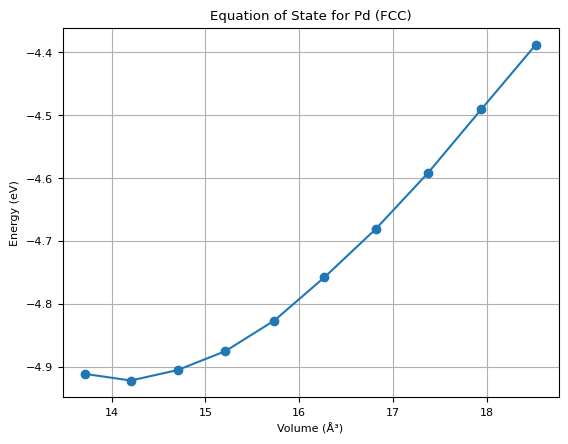

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from ase import Atoms
from gpaw import GPAW, PW

# Set up values for lattice parameter 'a'
a_values = np.linspace(3.8, 4.2, 10)  # Adjust the range and number of points as needed
energies = []
volumes = []
start_time = time.time()

# Loop over each lattice parameter to calculate energy
for a in a_values:
    b = a / 2
    # Define the bulk structure
    bulk = Atoms('Pd',
                 cell=[[0, b, b],
                       [b, 0, b],
                       [b, b, 0]],
                 pbc=True)

    k = 4
    calc = GPAW(mode=PW(300),       # Plane-wave cutoff
                kpts=(k, k, k),     # k-points grid
                txt='d-fcc-a{a:.2f}.txt')  # Output file with varying name

    # Attach the calculator to the bulk structure
    bulk.calc = calc

    # Calculate the potential energy
    energy = bulk.get_potential_energy()
    volume = bulk.get_volume()

    # Store the energy and volume
    energies.append(energy)
    volumes.append(volume)

    # Clean up the calculator
    calc.write(f'Pd-fcc-a{a:.2f}.gpw')
    del bulk.calc  # Free memory
end_time = time.time()
print(f' GPAW execution time: {end_time - start_time:.2f} sec')
plt.figure()
plt.plot(volumes, energies, marker='o', linestyle='-')
plt.xlabel('Volume (Å³)')
plt.ylabel('Energy (eV)')
plt.title('Equation of State for Pd (FCC)')
plt.grid()
plt.show()


TO-DO: Draw EOS for GPAW & MACE
- set the same lattice parameter values for bulk energy calculations
- print both GPAW and MACE execution times
- plot EOS by GPAW and MACE in single plot for comparison
- del bulk.calc  # Free memory code

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/tmp/ipykernel_2852/2165835155.py:35: FutureWarning: Please use atoms.calc = None
  del bulk.calc  # Free memory
/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/tmp/ipykernel_2852/2165835155.py:35: FutureWarning: Please use atoms.calc = None
  del bulk.calc  # Free memory
/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


...

Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/tmp/ipykernel_2852/2165835155.py:35: FutureWarning: Please use atoms.calc = None
  del bulk.calc  # Free memory


 Mace execution time: 2.19 sec


/tmp/ipykernel_2852/2165835155.py:70: FutureWarning: Please use atoms.calc = None
  del bulk.calc  # Free memory


 gpaw execution time: 20.48 sec


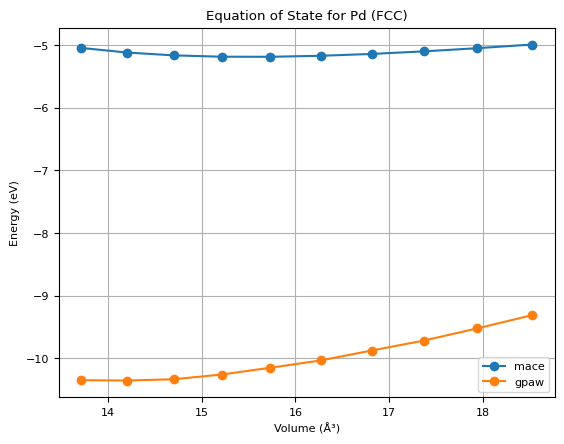

In [17]:
a_values = np.linspace(3.8, 4.2, 10)  # Adjust the range and number of points as needed
mace_energies = []
mace_volumes = []
gpaw_energies = []
gpaw_volumes = []
start_time = time.time()

for a in a_values:
    b = a / 2
    # Define the bulk structure
    bulk = Atoms('Pd',
                 cell=[[0, b, b],
                       [b, 0, b],
                       [b, b, 0]],
                 pbc=True)

    k = 4

#------------------------------------------------------------------------------------------------

    # Attach the calculator to the bulk structure
    mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float32", device='cuda')
    bulk.calc = mace_calc

    # Calculate the potential energy
    mace_energy = bulk.get_potential_energy()
    mace_volume = bulk.get_volume()

    # Store the energy and volume
    mace_energies.append(mace_energy)
    mace_volumes.append(mace_volume)

    # Clean up the calculator
    calc.write(f'Pd-fcc-a{a:.2f}.gpw')
    del bulk.calc  # Free memory

end_time = time.time()
print(f' Mace execution time: {end_time - start_time:.2f} sec')

 #----------------------------------------------------------------------------------------------
start_time = time.time()

for a in a_values:
    b = a / 2
    # Define the bulk structure
    bulk = Atoms('Pd',
                 cell=[[0, b, b],
                       [b, 0, b],
                       [b, b, 0]],
                 pbc=True)

    k = 4

    # Attach the calculator to the bulk structure
    gapw_calc = GPAW(mode=PW(300), kpts= (k, k, k), txt='d-fcc-a{a:.2f}.txt')

    # Attach the calculator to the bulk structure
    bulk.calc = gpaw_calc

    # Calculate the potential energy
    gpaw_energy = bulk.get_potential_energy()
    gpaw_volume = bulk.get_volume()

    # Store the energy and volume
    gpaw_energies.append(gpaw_energy)
    gpaw_volumes.append(gpaw_volume)

    # Clean up the calculator
    calc.write(f'Pd-fcc-a{a:.2f}.gpw')
    del bulk.calc  # Free memory


end_time = time.time()
print(f' gpaw execution time: {end_time - start_time:.2f} sec')


#------------------------------------------------------------------------------------------------


plt.figure()

plt.plot(mace_volumes, mace_energies, label='mace', marker='o', linestyle='-')  # 첫 번째 그래프
plt.plot(gpaw_volumes, gpaw_energies, label='gpaw', marker='o', linestyle='-')  # 두 번째 그래프
plt.legend()  # 범례 표시

plt.xlabel('Volume (Å³)')
plt.ylabel('Energy (eV)')
plt.title('Equation of State for Pd (FCC)')
plt.grid()
plt.show()


## 2. Surface Energy Calculations

We will run a full relaxation !

In [18]:
from ase.optimize import LBFGS
import copy
from ase.build import bulk
from ase.filters import ExpCellFilter  # ase.constraints --> ase.filters

# Define a function to execute full relaxation
def energy_cal(atoms,calc,lattice_relax = True,relax_atoms = True,fmax=0.05):
    if not relax_atoms:
        atoms_copied = copy.deepcopy(atoms)
    else:
        atoms_copied = atoms
    atoms_copied.calc = calc
    tags = np.ones(len(atoms_copied))
    atoms_copied.set_tags(tags)
    if lattice_relax:
      ecf = ExpCellFilter(atoms_copied)
      optimizer = LBFGS(ecf)
    else:
      optimizer = LBFGS(atoms_copied)
    optimizer.run(fmax=fmax)
    return atoms_copied.get_potential_energy()

In [19]:
import time
import numpy as np
from ase.build import fcc100, fcc110, fcc111,bulk
from ase.constraints import FixAtoms
from gpaw import GPAW, PW
from mace.calculators import mace_mp

element='Pd'
mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float32",device= "cpu")
bulk_pd=bulk(element, 'fcc')

# Single point calculation
bulk_atoms = bulk_pd.copy()
bulk_atoms.calc = mace_calc

E_bulk_single_point = bulk_atoms.get_potential_energy()###TO-DO
E_bulk_per_atom_sp = E_bulk_single_point / len(bulk_atoms)
print(f"Single point result: {E_bulk_per_atom_sp = :.2f} eV")

# Full relaxation calculation
bulk_atoms_fr = bulk_pd.copy()
E_bulk_full_relax = energy_cal(bulk_atoms_fr,mace_calc,lattice_relax=True)
E_bulk_per_atom_fr = E_bulk_full_relax/ len(bulk_atoms_fr) ### TO-DO
print(f"Full relaxation result: {E_bulk_per_atom_fr = :.2f} eV")

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
Single point result: E_bulk_per_atom_sp = -5.16 eV
       Step     Time          Energy          fmax
LBFGS:    0 05:46:35       -5.163897        0.936394
LBFGS:    1 05:46:35       -5.186124        0.199281


/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


LBFGS:    2 05:46:35       -5.187301        0.022182
Full relaxation result: E_bulk_per_atom_fr = -5.19 eV


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:46:53       -5.163897        0.936394
LBFGS:    1 05:46:53       -5.186124        0.199281
LBFGS:    2 05:46:53       -5.187301        0.022182
(calc : MACE) E_bulk : -5.19 eV
       Step     Time          Energy          fmax
LBFGS:    0 05:46:53      -19.400215        0.338160
LBFGS:    1 05:46:53      -19.404720        0.298002
LBFGS:    2 05:46:53      -19.421259        0.067555
LBFGS:    3 05:46:53      -19.421892        0.057006
LBFGS:    4 05:46:53      -19.423204        0.053532
LBFGS:    5 05:46:53      -19.427015        0.052145
LBFGS:    6 05:46:54      -19.432655        0.063804
LBFGS:    7 05:46:54      -19.431839        0.056576
LBFGS:    8 05:46:54      -19.430187        0.037082
(calc : MACE) Surface: fcc100
(calc : MACE) Potential Energy: -19.43 eV
(calc : MACE) Time taken: 1.39 seconds


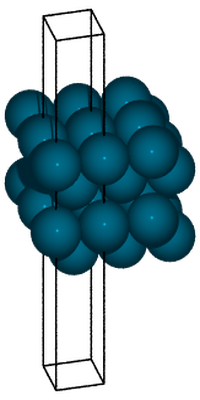

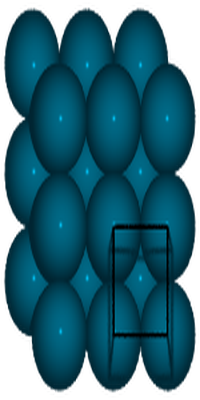

fcc100(calc : MACE) surface energy: 0.09 

       Step     Time          Energy          fmax
LBFGS:    0 05:46:57      -18.551546        0.720549
LBFGS:    1 05:46:57      -18.562147        0.646299


/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


LBFGS:    2 05:46:58      -18.612652        0.091657
LBFGS:    3 05:46:58      -18.616884        0.079119
LBFGS:    4 05:46:58      -18.619984        0.089758
LBFGS:    5 05:46:58      -18.626904        0.123748
LBFGS:    6 05:46:58      -18.635201        0.296239
LBFGS:    7 05:46:58      -18.035147        2.373956
LBFGS:    8 05:46:58      -18.635187        0.303106
LBFGS:    9 05:46:58      -18.619511        0.107611
LBFGS:   10 05:46:58      -18.325006        1.560562
LBFGS:   11 05:46:58      -18.620478        0.121681
LBFGS:   12 05:46:58      -18.490856        0.165647
LBFGS:   13 05:46:58      -18.633713        0.333100
LBFGS:   14 05:46:59      -18.377617        1.376873
LBFGS:   15 05:46:59      -18.611910        0.119093
LBFGS:   16 05:46:59      -18.445627        0.189167
LBFGS:   17 05:46:59      -18.634655        0.318489
LBFGS:   18 05:46:59      -18.440638        1.174845
LBFGS:   19 05:46:59      -18.595898        0.116849
LBFGS:   20 05:46:59      -18.275099        0.

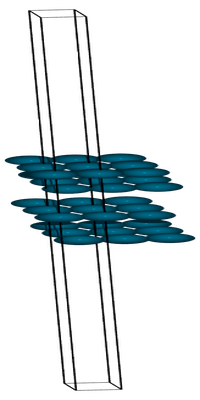

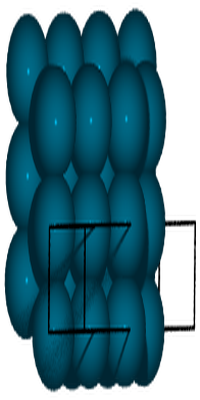

fcc110(calc : MACE) surface energy: 0.447 

       Step     Time          Energy          fmax
LBFGS:    0 05:47:49      -19.631628        0.360835
LBFGS:    1 05:47:49      -19.641008        0.299377


/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


LBFGS:    2 05:47:49      -19.667212        0.128346
LBFGS:    3 05:47:49      -19.667912        0.115311
LBFGS:    4 05:47:49      -19.668516        0.073960
LBFGS:    5 05:47:49      -19.669445        0.040535
(calc : MACE) Surface: fcc111
(calc : MACE) Potential Energy: -19.67 eV
(calc : MACE) Time taken: 0.90 seconds


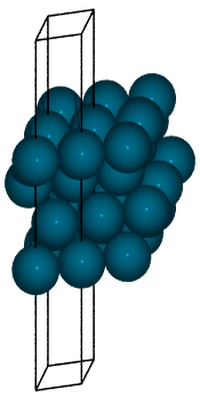

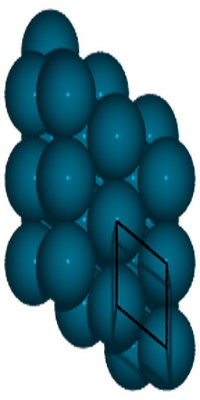

fcc111(calc : MACE) surface energy: 0.081 



In [20]:
element='Pd'
size = 1  # supercell size
vac = 7.5  # vacuum size
N_layer = 4

calc_name, calc ='MACE' , mace_mp(model="medium",  dispersion=False,  default_dtype="float32",  device= "cpu")

bulk_atoms = bulk(element, 'fcc')
bulk_atoms.calc = calc
E_bulk = energy_cal(bulk_atoms,calc,lattice_relax=True)
print(f"(calc : {calc_name}) E_bulk : {E_bulk:.2f} eV")
fcc_surfaces = [('fcc100', fcc100), ('fcc110', fcc110), ('fcc111', fcc111)]


for surface_name, surface_function in fcc_surfaces:

    surf = surface_function(element, (size, size, N_layer), vacuum=vac)
    median_z = np.median(surf.positions[:, 2])
    constraint = FixAtoms(mask=[atom.position[2] < (median_z + 0.01) for atom in surf])
    surf.set_constraint(constraint)
    surf.calc = calc

    start_time = time.time()
    e = energy_cal(surf,calc,lattice_relax=True) # full relaxation
    elapsed_time = time.time() - start_time

    # Print the results
    print(f'(calc : {calc_name}) Surface: {surface_name}')
    print(f'(calc : {calc_name}) Potential Energy: {e:.2f} eV')
    print(f'(calc : {calc_name}) Time taken: {elapsed_time:.2f} seconds')

    a1 = surf.get_cell()[0]  # First lattice vector (in the surface plane)
    a2 = surf.get_cell()[1]  # Second lattice vector (in the surface plane)
    # Calculate the surface area as the magnitude of the cross product
    A = np.linalg.norm(np.cross(a1, a2))
    E_slab= surf.get_potential_energy()
    enlarge_and_visual(surf)
    enlarge_and_visual(surf,angle='90z,-0x') # topview
    n_atoms = len(surf)  # number of atoms in the slab

    surface_energy = (E_slab - n_atoms * E_bulk) / (2 * A)
    print(f'{surface_name}(calc : {calc_name}) surface energy:',round(surface_energy,3),'\n')

## 3. CO Adsorption Energy Calculation

/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:09      -19.654586        0.063610
LBFGS:    1 05:48:09      -19.656956        0.057661
LBFGS:    2 05:48:09      -19.667845        0.127662
LBFGS:    3 05:48:09      -19.667824        0.125441
LBFGS:    4 05:48:09      -19.650138        0.083084
LBFGS:    5 05:48:09      -19.667723        0.059673
LBFGS:    6 05:48:09      -19.671063        0.037112
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:09      -14.392697        6.743168
LBFGS:    1 05:48:09      -12.536459       16.867303
LBFGS:    2 05:48:09      -14.433309        4.857181
LBFGS:    3 05:48:09      -14.340495        8.247507
LBFGS:    4 05:48:09      -14.515866        0.523552
LBFGS:    5 05:48:09      -14.519635        0.268503
LBFGS:    6 05:48:10      -14.530220        1.056352
LBFGS:    7 05:48:10      -14.538278        1.236077
LBFGS:    8 05:48:10      -14.555457        0.929886
LBFGS:    9 05:48:10      -14.566271        0.516996
LBFGS:   10 05:48:10      -14.567690        0.154191
LBFGS:   11 05:48:10      -14.568112        0.362507
LBFGS:   12 05:48:10      -14.569033        0.576314
LBFGS:   13 05:48:10      -14.570863        0.631162
LBFGS:   14 05:48:10      -14.574804        0.594208
LBFGS:   15 05:48:10      -14.578773        0.097167
LBFGS:   16 05:48:10      -14.579186        0.253627
LBFGS:   17 05:48:10      -14.579440        0.09

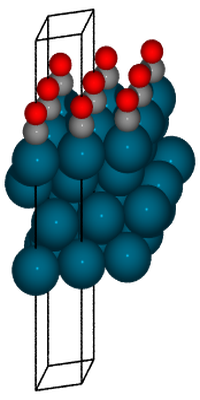

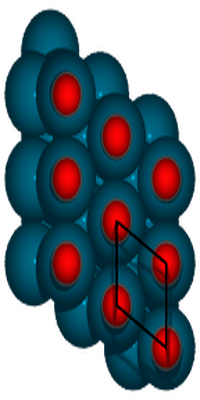

/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:13      -34.985370        1.294532
LBFGS:    1 05:48:13      -34.999008        2.552093
LBFGS:    2 05:48:13      -35.040175        1.167202
LBFGS:    3 05:48:13      -35.066194        0.393125
LBFGS:    4 05:48:13      -35.077020        0.332418
LBFGS:    5 05:48:13      -35.085713        0.379960
LBFGS:    6 05:48:13      -35.090373        0.336070
LBFGS:    7 05:48:13      -35.095098        0.174417
LBFGS:    8 05:48:13      -35.097011        0.084838
LBFGS:    9 05:48:13      -35.097591        0.086399
LBFGS:   10 05:48:13      -35.098085        0.096735
LBFGS:   11 05:48:13      -35.098690        0.085744
LBFGS:   12 05:48:13      -35.100058        0.051538
LBFGS:   13 05:48:13      -35.098993        0.075637
LBFGS:   14 05:48:14      -35.095505        0.081262
LBFGS:   15 05:48:14      -35.095250        0.067452
LBFGS:   16 05:48:14      -35.097833        0.043916
(calc = MACE) Adsorption energy: -0.85 eV
(calc 

/tmp/ipykernel_2852/1566547139.py:47: FutureWarning: Please use atoms.calc = None
  del adslab.calc


LBFGS:    1 05:48:14      -12.536459       16.867303
LBFGS:    2 05:48:14      -14.433309        4.857181
LBFGS:    3 05:48:14      -14.340495        8.247507
LBFGS:    4 05:48:14      -14.515866        0.523552
LBFGS:    5 05:48:14      -14.519635        0.268503
LBFGS:    6 05:48:14      -14.530220        1.056352
LBFGS:    7 05:48:14      -14.538278        1.236077
LBFGS:    8 05:48:14      -14.555457        0.929886
LBFGS:    9 05:48:14      -14.566271        0.516996
LBFGS:   10 05:48:14      -14.567690        0.154191
LBFGS:   11 05:48:14      -14.568112        0.362507
LBFGS:   12 05:48:14      -14.569033        0.576314
LBFGS:   13 05:48:14      -14.570863        0.631162
LBFGS:   14 05:48:14      -14.574804        0.594208
LBFGS:   15 05:48:14      -14.578773        0.097167
LBFGS:   16 05:48:14      -14.579186        0.253627
LBFGS:   17 05:48:14      -14.579440        0.094656
LBFGS:   18 05:48:14      -14.579488        0.022951
size: <<<2x2>>>
       Step     Time          

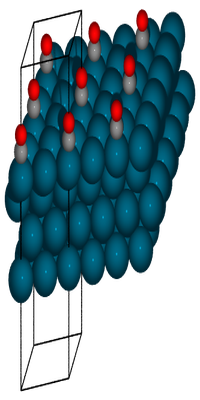

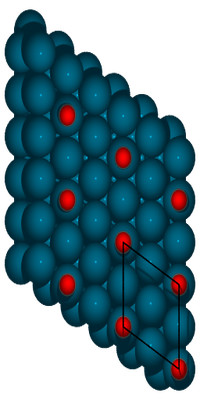

/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:18      -94.024548        1.414510
LBFGS:    1 05:48:18      -94.042166        2.447267
LBFGS:    2 05:48:18      -94.081180        1.053562
LBFGS:    3 05:48:18      -94.101623        0.211662
LBFGS:    4 05:48:18      -94.106866        0.244855
LBFGS:    5 05:48:18      -94.109725        0.176386
LBFGS:    6 05:48:18      -94.112606        0.077156
LBFGS:    7 05:48:18      -94.112697        0.066294
LBFGS:    8 05:48:18      -94.113611        0.075213
LBFGS:    9 05:48:18      -94.114364        0.055138
LBFGS:   10 05:48:18      -94.114401        0.039175
(calc = MACE) Adsorption energy: -11.78 eV
(calc = MACE) Time taken: 4.09 seconds



/tmp/ipykernel_2852/1566547139.py:47: FutureWarning: Please use atoms.calc = None
  del adslab.calc


       Step     Time          Energy          fmax
LBFGS:    0 05:48:19      -14.392697        6.743168
LBFGS:    1 05:48:19      -12.536459       16.867303
LBFGS:    2 05:48:19      -14.433309        4.857181
LBFGS:    3 05:48:19      -14.340495        8.247507
LBFGS:    4 05:48:19      -14.515866        0.523552
LBFGS:    5 05:48:19      -14.519635        0.268503
LBFGS:    6 05:48:19      -14.530220        1.056352
LBFGS:    7 05:48:19      -14.538278        1.236077
LBFGS:    8 05:48:19      -14.555457        0.929886
LBFGS:    9 05:48:19      -14.566271        0.516996
LBFGS:   10 05:48:19      -14.567690        0.154191
LBFGS:   11 05:48:19      -14.568112        0.362507
LBFGS:   12 05:48:19      -14.569033        0.576314
LBFGS:   13 05:48:19      -14.570863        0.631162
LBFGS:   14 05:48:19      -14.574804        0.594208
LBFGS:   15 05:48:19      -14.578773        0.097167
LBFGS:   16 05:48:19      -14.579186        0.253627
LBFGS:   17 05:48:19      -14.579440        0.09

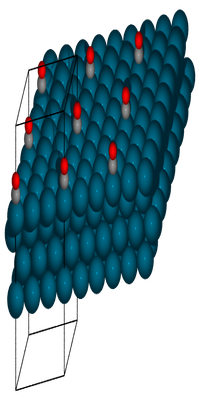

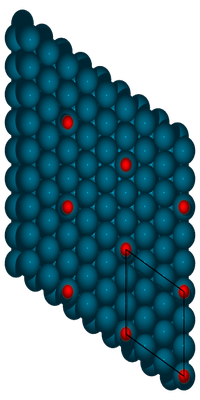

/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:25     -192.402990        1.417669
LBFGS:    1 05:48:25     -192.414118        2.392521
LBFGS:    2 05:48:25     -192.446666        0.907501
LBFGS:    3 05:48:25     -192.465365        0.257392
LBFGS:    4 05:48:26     -192.473038        0.369823
LBFGS:    5 05:48:26     -192.475349        0.237249
LBFGS:    6 05:48:26     -192.477904        0.135832
LBFGS:    7 05:48:26     -192.479175        0.121668
LBFGS:    8 05:48:26     -192.479469        0.151999
LBFGS:    9 05:48:26     -192.479855        0.129607
LBFGS:   10 05:48:27     -192.480531        0.075524
LBFGS:   11 05:48:27     -192.481023        0.066928
LBFGS:   12 05:48:27     -192.481087        0.100522
LBFGS:   13 05:48:27     -192.481053        0.112586
LBFGS:   14 05:48:27     -192.481436        0.096010
LBFGS:   15 05:48:27     -192.482324        0.051503
LBFGS:   16 05:48:27     -192.482927        0.033126
(calc = MACE) Adsorption energy: -13.82 eV
(calc

/tmp/ipykernel_2852/1566547139.py:47: FutureWarning: Please use atoms.calc = None
  del adslab.calc


LBFGS:    5 05:48:28      -14.519635        0.268503
LBFGS:    6 05:48:28      -14.530220        1.056352
LBFGS:    7 05:48:28      -14.538278        1.236077
LBFGS:    8 05:48:28      -14.555457        0.929886
LBFGS:    9 05:48:28      -14.566271        0.516996
LBFGS:   10 05:48:28      -14.567690        0.154191
LBFGS:   11 05:48:28      -14.568112        0.362507
LBFGS:   12 05:48:28      -14.569033        0.576314
LBFGS:   13 05:48:28      -14.570863        0.631162
LBFGS:   14 05:48:28      -14.574804        0.594208
LBFGS:   15 05:48:28      -14.578773        0.097167
LBFGS:   16 05:48:28      -14.579186        0.253627
LBFGS:   17 05:48:28      -14.579440        0.094656
LBFGS:   18 05:48:28      -14.579488        0.022951
size: <<<4x4>>>
       Step     Time          Energy          fmax
LBFGS:    0 05:48:28     -314.737000        0.223745
LBFGS:    1 05:48:29     -314.738737        0.188174
LBFGS:    2 05:48:29     -314.745510        0.067672
LBFGS:    3 05:48:29     -314.74

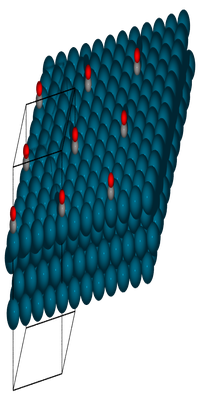

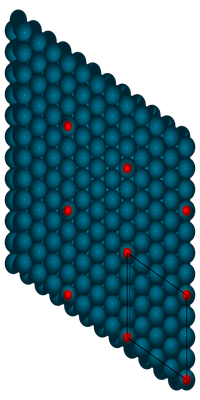

/tmp/ipykernel_2852/1693610439.py:16: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 05:48:36     -330.100524        1.416771
LBFGS:    1 05:48:36     -330.109617        2.448995
LBFGS:    2 05:48:36     -330.142394        0.922465
LBFGS:    3 05:48:36     -330.162123        0.448261
LBFGS:    4 05:48:37     -330.172169        0.397253
LBFGS:    5 05:48:37     -330.175103        0.369092
LBFGS:    6 05:48:37     -330.178094        0.172112
LBFGS:    7 05:48:37     -330.179064        0.168820
LBFGS:    8 05:48:38     -330.179779        0.263600
LBFGS:    9 05:48:38     -330.180767        0.203219
LBFGS:   10 05:48:38     -330.181586        0.078256
LBFGS:   11 05:48:38     -330.181906        0.116399
LBFGS:   12 05:48:38     -330.182081        0.197890
LBFGS:   13 05:48:39     -330.182506        0.224418
LBFGS:   14 05:48:39     -330.183535        0.152423
LBFGS:   15 05:48:39     -330.184297        0.042414
(calc = MACE) Adsorption energy: -14.53 eV
(calc = MACE) Time taken: 10.90 seconds



/tmp/ipykernel_2852/1566547139.py:47: FutureWarning: Please use atoms.calc = None
  del adslab.calc


In [22]:
from fractions import Fraction
from ase.build import add_adsorbate

# Initialize the parameters
a0 = 3.95  # fcc lattice parameter
element='Pd'
N_layer = 4 # number of layers
size = 1 #  supercell size
vac = 7.5


surf = fcc111(element, (size, size, N_layer), a=a0, vacuum=vac)
median_z = np.median(surf.positions[:, 2])
constraint = FixAtoms(mask=[atom.position[2] < (median_z + 0.01) for atom in surf])
surf.set_constraint(constraint)
E_slab = energy_cal(surf,calc)

CO_binding_list=[]
calc_name, calc ='MACE' , mace_mp(model="medium",  dispersion=False,  default_dtype="float64",  device= "cuda")
sizes = [1, 2, 3, 4]

for size in sizes:
    CO = Atoms('CO',
                positions=[(0, 0, 0),
                            (0, 0, 1.1)],
                cell=(a, a, a),pbc='TRUE')

    CO.calc = calc
    E_CO = energy_cal(CO,calc)

    coverage = Fraction(1, size*size)
    print(f'size: <<<{size}x{size}>>>')
    start_time = time.time()  # Start timing
    adslab = surf.copy()
    adslab=adslab * (size,size,1) ## BECAREFUL YOUR CALCULATION COULD BE EXTREAMELY HEAVY for size 3 or more
    E_slab = energy_cal(adslab, calc) # 오타, calc 빠짐

    add_adsorbate(adslab, CO, 1.8, 'ontop')
    enlarge_and_visual(adslab)
    enlarge_and_visual(adslab,angle='90z,-0x') # topview

    adslab.calc = calc
    E_adslab =  energy_cal(adslab,calc)

    E_ads = E_adslab - E_slab - E_CO * coverage
    CO_binding_list.append(E_ads)
    del adslab.calc

    elapsed_time = time.time() - start_time
    # Print results
    print(f'(calc = {calc_name}) Adsorption energy: {round(E_ads, 2)} eV')
    print(f'(calc = {calc_name}) Time taken: {elapsed_time:.2f} seconds\n')

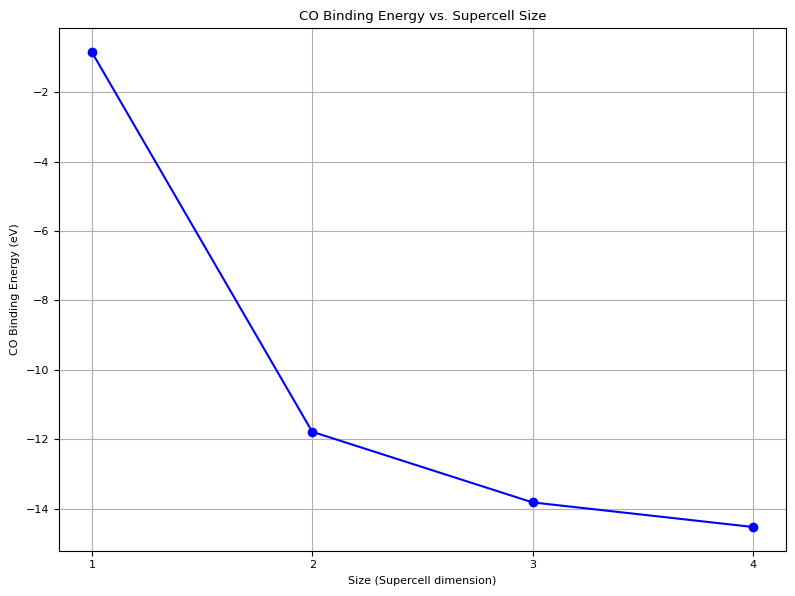

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(sizes, CO_binding_list, marker='o', linestyle='-', color='b')
plt.xlabel("Size (Supercell dimension)")
plt.ylabel("CO Binding Energy (eV)")
plt.title("CO Binding Energy vs. Supercell Size")
plt.xticks(sizes)
plt.grid(True)
plt.tight_layout()
plt.show()

# __Potential energy surface Visualization__: H diffusion on Pt(111)

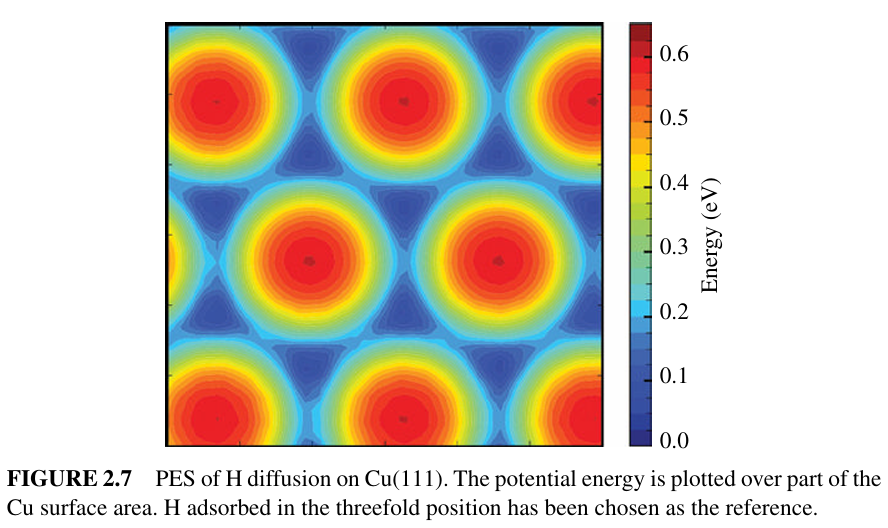

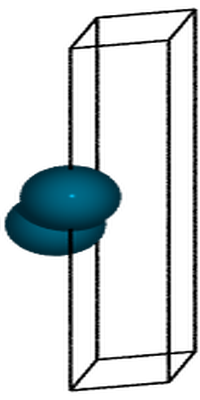

In [24]:
# make Pd 111 slab
from ase.build import fcc111

a0 = 3.95 ### TO-DO: Use your lattice parameter
vac = 7.5
pd111_surf = fcc111(element, (1, 1, 2), a=a0, vacuum=vac)

visual(pd111_surf)

In [25]:
from tqdm import tqdm

pd_z_max = np.max(pd111_surf.positions[:,-1])
pd_lattice_a, pd_lattice_b, _ = pd111_surf.cell.array[0], pd111_surf.cell.array[1], pd111_surf.cell.array[2]

a_num = 40
b_num = 40

a_range = np.linspace(0,1,a_num)
b_range = np.linspace(0,1,b_num)

E_heatmap = np.zeros([a_num,b_num])
mace_calc = mace_mp(model="small", dispersion=False, default_dtype="float32", device='cuda')

total_steps = a_num * b_num
with tqdm(total=total_steps, desc="Total Progress") as pbar:
    for idx_a, a in enumerate(a_range):
        for idx_b, b in enumerate(b_range):
            a_vec = pd_lattice_a * a
            b_vec = pd_lattice_b * b
            c_vec = np.array([0, 0, pd_z_max + 1.39])
            h_positions = a_vec + b_vec + c_vec

            H_atoms = Atoms(symbols=['H'], positions=[h_positions.tolist()])
            pd111_adslab = pd111_surf + H_atoms

            pd111_adslab.calc = mace_calc
            E_heatmap[idx_a, idx_b] = pd111_adslab.get_potential_energy()

            pbar.update(1)
print("Done!")

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


Total Progress: 100%|██████████| 1600/1600 [00:49<00:00, 32.63it/s]

Done!


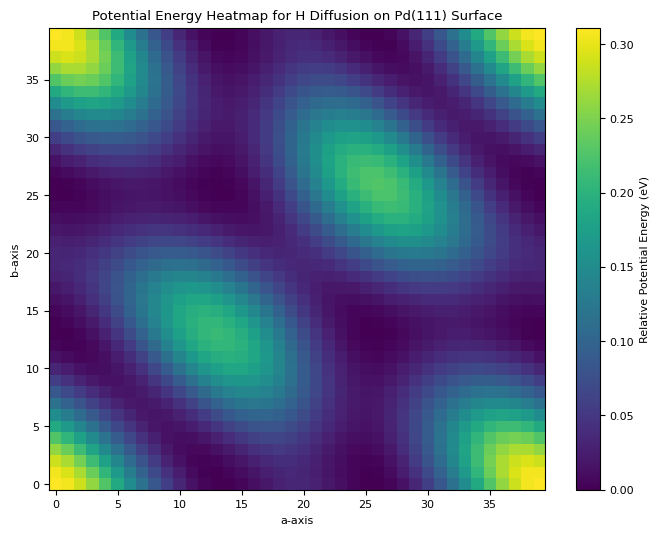

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

E_heatmap = E_heatmap - np.min(E_heatmap)

plt.figure(figsize=(8, 6))
heatmap = plt.imshow(E_heatmap, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(heatmap, label="Relative Potential Energy (eV)")  # Add color bar with label

plt.xlabel("a-axis")
plt.ylabel("b-axis")
plt.title("Potential Energy Heatmap for H Diffusion on Pd(111) Surface")

# Show plot
plt.show()

# __[TO-DO]__
# __Optimization of the adsorption configuration of OH on FCC metal__

In [27]:
from ase.optimize import LBFGS
import copy
from ase.build import bulk
from ase.filters import ExpCellFilter # ase.constraints --> ase.filters

def energy_cal(atoms,calc,lattice_relax = False,relax_atoms = True,fmax=0.05):
    if not relax_atoms:
        atoms_copied = copy.deepcopy(atoms)
    else:
        atoms_copied = atoms
    atoms_copied.calc = calc
    tags = np.ones(len(atoms_copied))
    atoms_copied.set_tags(tags)
    if lattice_relax:
      ecf = ExpCellFilter(atoms_copied)
      optimizer = LBFGS(ecf)
    else:
      optimizer = LBFGS(atoms_copied)
    optimizer.run(fmax=fmax)
    return atoms_copied.get_potential_energy()

### Step 1. [TO-DO] Bulk optimization
- Use your metal element to calculate bulk energy (per atom)
- print: E_bulk_per_atom: {} eV

In [29]:
name = 'Pd'
a0 = 3.95
element= 'Pd'

bulk_atoms = bulk(element, 'fcc', a=a0)
mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float32", device='cuda')


E_bulk = energy_cal(bulk_atoms,mace_calc,lattice_relax=True)
E_bulk_per_atom = E_bulk/ len(bulk_atoms)


print(f"{E_bulk_per_atom = :.2f} eV")

/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/tmp/ipykernel_2852/1650758633.py:15: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ecf = ExpCellFilter(atoms_copied)


       Step     Time          Energy          fmax
LBFGS:    0 06:20:21       -5.187023        0.097933
LBFGS:    1 06:20:21       -5.187289        0.029289
E_bulk_per_atom = -5.19 eV


### Step 2. [TO-DO] Facet Optimization
- optimize facets for miller indexes (1,0,0), (1,1,0),(1,1,1), (2,1,0),(2,1,1)
- set constraint for bottom 4 layers and relax 2 surface layers
- print Slab potential energy, surface energy, elapsed time & visualize slab for each facet

Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


       Step     Time          Energy          fmax
LBFGS:    0 06:27:12     -479.280127        0.000000
Miller index: (1, 0, 0)
  N_atoms         : 96
  Slab energy     : -479.2801 eV
  Surface energy  : 1.4288 J/m²
  Elapsed time    : 0.8 s



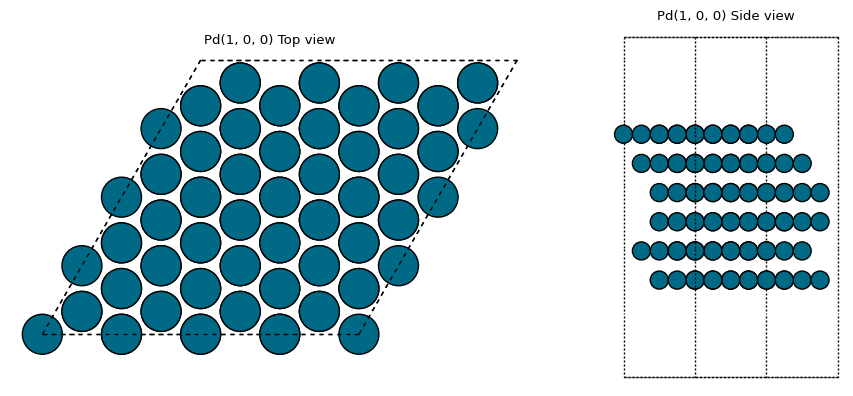

       Step     Time          Energy          fmax
LBFGS:    0 06:27:15     -475.428142        0.000000
Miller index: (1, 1, 0)
  N_atoms         : 96
  Slab energy     : -475.4281 eV
  Surface energy  : 1.4923 J/m²
  Elapsed time    : 0.5 s



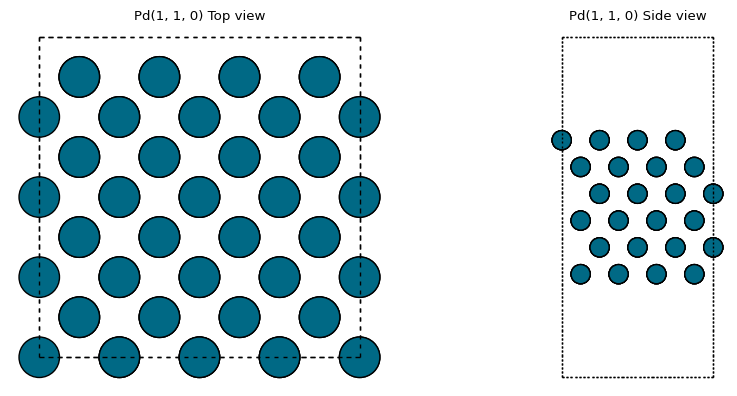

       Step     Time          Energy          fmax
LBFGS:    0 06:27:17     -479.280127        0.000000
Miller index: (1, 1, 1)
  N_atoms         : 96
  Slab energy     : -479.2801 eV
  Surface energy  : 1.4288 J/m²
  Elapsed time    : 0.3 s



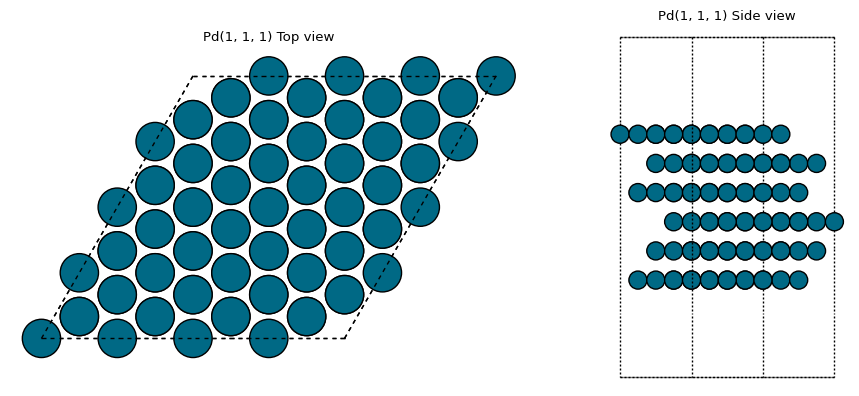

       Step     Time          Energy          fmax
LBFGS:    0 06:27:19     -457.813929        0.000000
Miller index: (2, 1, 0)
  N_atoms         : 96
  Slab energy     : -457.8139 eV
  Surface energy  : 1.6027 J/m²
  Elapsed time    : 0.3 s



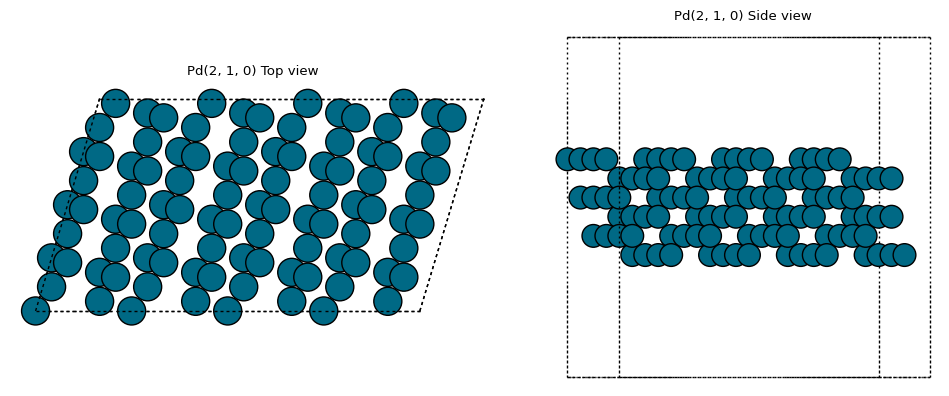

       Step     Time          Energy          fmax
LBFGS:    0 06:27:21     -462.579503        0.000000
Miller index: (2, 1, 1)
  N_atoms         : 96
  Slab energy     : -462.5795 eV
  Surface energy  : 1.6563 J/m²
  Elapsed time    : 0.3 s



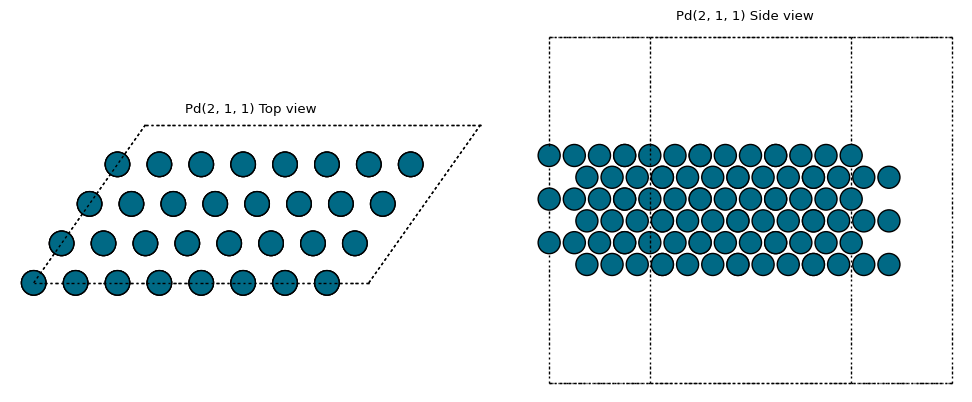

In [35]:
# facet optimization

from ase.build import bulk, surface

size = 4 #  supercell size
vac = 7.5

miller_index_list = [(1,0,0),(1,1,0),(1,1,1),(2,1,0),(2,1,1)]
N_bulk_layer = 4 # Bottom layers to fix
N_surface_layer = 2 # Surface layers to relax
n_atoms_list = []
surface_energy_list = []
time_list = []
mace_calc = mace_mp(model="medium", dispersion=False, default_dtype="float64", device='cuda')

### TO-DO

### TO-DO
for miller in miller_index_list:
    start_time = time.time()

    # 1. Slab 생성
    bulk_pd = bulk('Pd', 'fcc')
    slab = surface(bulk_pd, miller, layers=N_bulk_layer + N_surface_layer, vacuum=vac)
    slab = slab.repeat([size, size, 1])  # xy 방향 supercell

    # 2. 하단 N_bulk_layer 레이어 고정
    z_positions = slab.positions[:, 2]
    z_sorted = np.sort(np.unique(z_positions.round(2)))

    fixed_z = z_sorted[:N_bulk_layer * size]  # 하단 레이어 z값
    fixed_indices = [i for i, atom in enumerate(slab)
                     if round(atom.position[2], 2) in np.round(fixed_z, 2)]

    slab.set_constraint(FixAtoms(indices=fixed_indices))

    # 3. Relaxation (상단 2 레이어만 움직임)
    E_slab = energy_cal(slab, mace_calc, lattice_relax=False, relax_atoms=True)

    # 4. Surface energy 계산
    # γ = (E_slab - N_atoms * E_bulk_per_atom) / (2 * A)
    N_atoms = len(slab)
    A = np.linalg.norm(np.cross(slab.cell[0], slab.cell[1]))  # 표면적 (Å²)
    E_surf = (E_slab - N_atoms * E_bulk_per_atom_fr) / (2 * A)
    E_surf_Jm2 = E_surf * 16.02  # eV/Å² → J/m² 변환

    elapsed = time.time() - start_time

    # 5. 결과 저장 및 출력
    n_atoms_list.append(N_atoms)
    surface_energy_list.append(E_surf_Jm2)
    time_list.append(elapsed)

    print(f"Miller index: {miller}")
    print(f"  N_atoms         : {N_atoms}")
    print(f"  Slab energy     : {E_slab:.4f} eV")
    print(f"  Surface energy  : {E_surf_Jm2:.4f} J/m²")
    print(f"  Elapsed time    : {elapsed:.1f} s")
    print()

    # 6. 시각화
    from ase.visualize.plot import plot_atoms
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    plot_atoms(slab, ax[0], radii=0.5, rotation='0x,0y,0z')  # top view
    plot_atoms(slab, ax[1], radii=0.5, rotation='90x,0y,0z')  # side view
    ax[0].set_title(f"Pd{miller} Top view")
    ax[1].set_title(f"Pd{miller} Side view")
    plt.tight_layout()
    plt.show()

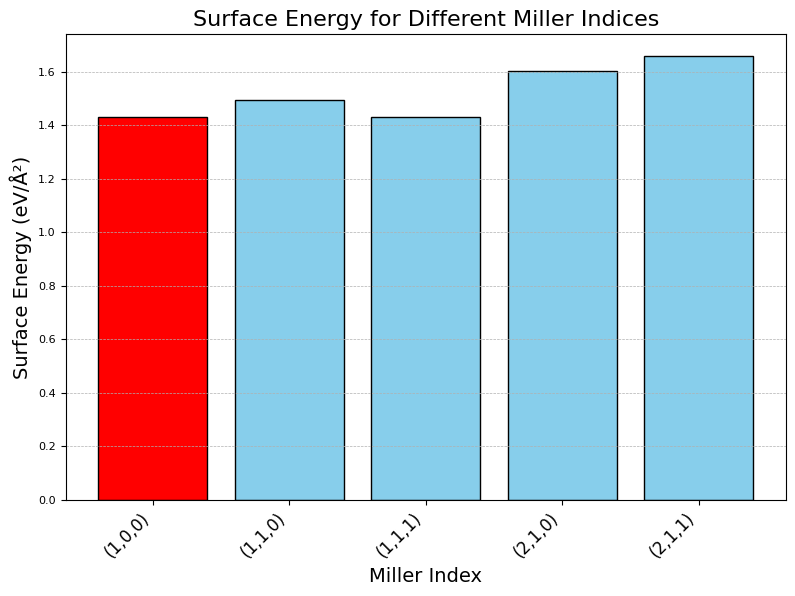

In [36]:
# Plot surface energy for each miller index
%matplotlib inline
miller_index_labels = ['({},{},{})'.format(*index) for index in miller_index_list]

min_energy = min(surface_energy_list)
min_energy_index = surface_energy_list.index(min_energy)

colors = ['skyblue' if i != min_energy_index else 'red' for i in range(len(surface_energy_list))]

plt.figure(figsize=(8, 6))
plt.bar(miller_index_labels, surface_energy_list, color=colors, edgecolor='black')

plt.title('Surface Energy for Different Miller Indices', fontsize=16)
plt.xlabel('Miller Index', fontsize=14)
plt.ylabel('Surface Energy (eV/Å²)', fontsize=14)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

### STEP 3: Adsorbate OH optimization

       Step     Time          Energy          fmax
LBFGS:    0 06:27:47       -7.799503        0.305963
LBFGS:    1 06:27:47       -7.800459        0.084792
LBFGS:    2 06:27:47       -7.800541        0.001398


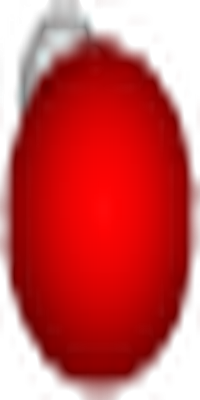

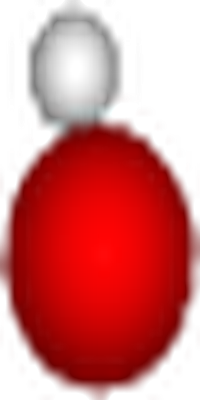

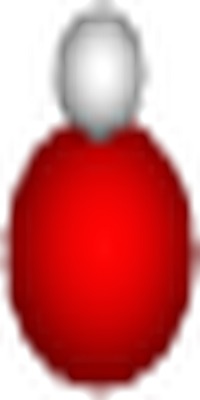

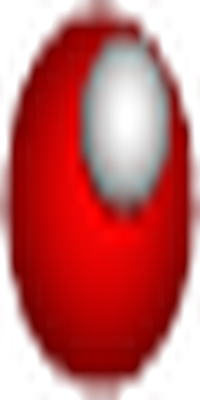

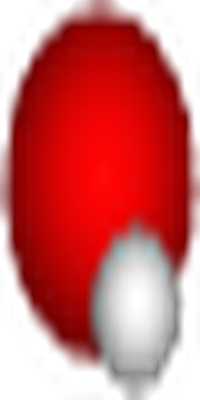

OH energy : -7.800541013951598


In [37]:
from ase.build import molecule

oh_atoms = molecule('OH')

O_index = [atom.index for atom in oh_atoms if atom.symbol == 'O'][0]
O_position = oh_atoms.positions[O_index]
oh_atoms.rotate(v='x', a=90, center=O_position)

oh_energy = energy_cal(oh_atoms,mace_calc,relax_atoms=False)

visual(oh_atoms)
oh_atoms.rotate(v='x', a=45, center=O_position)
visual(oh_atoms)
oh_atoms.rotate(v='x', a=45, center=O_position)
visual(oh_atoms)
oh_atoms.rotate(v='x', a=45, center=O_position)
visual(oh_atoms)
oh_atoms.rotate(v='x', a=45, center=O_position)
visual(oh_atoms)
oh_atoms.rotate(v='x', a=45, center=O_position)

print(f"OH energy : {oh_energy}")

### STEP 4: [TO-DO] Adsorption Site Enumeration
- Upon your optimized facet, set supercell size: 3, bulk layer:2 (to fix; total 4 layers)
- Adsorption site enumeration along a-b plane, rotation of OH

       Step     Time          Energy          fmax
LBFGS:    0 06:31:52     -176.684631        0.360836
LBFGS:    1 06:31:52     -176.701802        0.336924
LBFGS:    2 06:31:52     -176.877963        0.282972
LBFGS:    3 06:31:52     -176.895593        0.276634
LBFGS:    4 06:31:52     -176.919870        0.214007
LBFGS:    5 06:31:53     -176.937736        0.114371
LBFGS:    6 06:31:53     -176.945816        0.029104
Surface energy: 1.3307 J/m²


Total Progress:   0%|          | 0/20 [00:00<?, ?it/s]

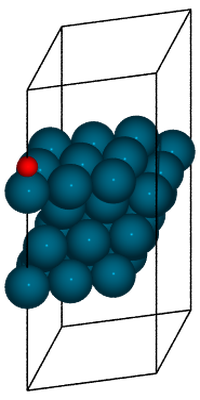

       Step     Time          Energy          fmax
LBFGS:    0 06:31:55     -177.655036       67.987955
LBFGS:    1 06:31:55      -84.817043     2887.092759
LBFGS:    2 06:31:55     -155.189560      627.539357
LBFGS:    3 06:31:56     -172.882538      161.816020
LBFGS:    4 06:31:56     -173.225049      184.954976
LBFGS:    5 06:31:56     -175.607321      225.611357
LBFGS:    6 06:31:56     -177.435457      100.811197
LBFGS:    7 06:31:56     -179.284915       76.786737
LBFGS:    8 06:31:56     -177.529102       83.679615
LBFGS:    9 06:31:56     -177.697253       71.388044
LBFGS:   10 06:31:57     -177.298827       81.951474
LBFGS:   11 06:31:57     -178.797900       49.796623
LBFGS:   12 06:31:57     -180.250519       44.098090
LBFGS:   13 06:31:57     -182.360299       17.058329
LBFGS:   14 06:31:57     -181.900678       24.797913
LBFGS:   15 06:31:57     -182.745421       22.440676
LBFGS:   16 06:31:57     -182.070101       39.333357
LBFGS:   17 06:31:58     -183.280241       10.69

Total Progress:   5%|▌         | 1/20 [00:24<07:39, 24.18s/it]

LBFGS:  151 06:32:17     -228.218540        0.017759


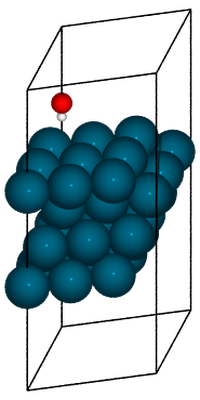

       Step     Time          Energy          fmax
LBFGS:    0 06:32:18     -177.655036       67.987955
LBFGS:    1 06:32:19      -84.817043     2887.092759
LBFGS:    2 06:32:19     -155.189560      627.539357
LBFGS:    3 06:32:19     -172.882538      161.816020
LBFGS:    4 06:32:19     -173.225049      184.954976
LBFGS:    5 06:32:19     -175.607321      225.611357
LBFGS:    6 06:32:19     -177.435457      100.811197
LBFGS:    7 06:32:19     -179.284915       76.786737
LBFGS:    8 06:32:20     -177.529102       83.679615
LBFGS:    9 06:32:20     -177.697253       71.388044
LBFGS:   10 06:32:20     -177.298827       81.951474
LBFGS:   11 06:32:20     -178.797900       49.796623
LBFGS:   12 06:32:20     -180.250519       44.098090
LBFGS:   13 06:32:20     -182.360299       17.058329
LBFGS:   14 06:32:20     -181.900678       24.797913
LBFGS:   15 06:32:21     -182.745421       22.440676
LBFGS:   16 06:32:21     -182.070101       39.333357
LBFGS:   17 06:32:21     -183.280241       10.69

Total Progress:  10%|█         | 2/20 [00:41<06:07, 20.41s/it]

LBFGS:  116 06:32:35     -228.218159        0.193609
LBFGS:  117 06:32:35     -228.218250        0.034125


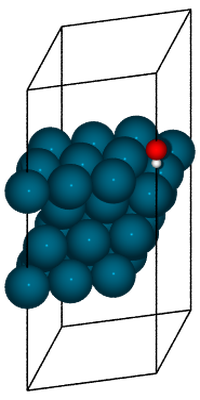

       Step     Time          Energy          fmax
LBFGS:    0 06:32:36     -177.655036       67.987955
LBFGS:    1 06:32:36      -84.817043     2887.092759
LBFGS:    2 06:32:36     -155.189560      627.539357
LBFGS:    3 06:32:36     -172.882538      161.816020
LBFGS:    4 06:32:37     -173.225049      184.954976
LBFGS:    5 06:32:37     -175.607321      225.611357
LBFGS:    6 06:32:37     -177.435457      100.811197
LBFGS:    7 06:32:37     -179.284915       76.786737
LBFGS:    8 06:32:37     -177.529102       83.679615
LBFGS:    9 06:32:37     -177.697253       71.388044
LBFGS:   10 06:32:37     -177.298827       81.951474
LBFGS:   11 06:32:38     -178.797900       49.796623
LBFGS:   12 06:32:38     -180.250519       44.098090
LBFGS:   13 06:32:38     -182.360299       17.058329
LBFGS:   14 06:32:38     -181.900678       24.797913
LBFGS:   15 06:32:38     -182.745421       22.440676
LBFGS:   16 06:32:38     -182.070101       39.333357
LBFGS:   17 06:32:38     -183.280241       10.69

Total Progress:  15%|█▌        | 3/20 [01:01<05:41, 20.11s/it]

LBFGS:  132 06:32:54     -228.218530        0.171217
LBFGS:  133 06:32:55     -228.218536        0.038340


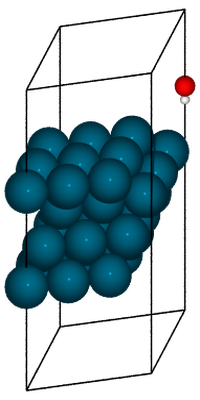

       Step     Time          Energy          fmax
LBFGS:    0 06:32:56     -177.655036       67.987955
LBFGS:    1 06:32:56      -84.817043     2887.092759
LBFGS:    2 06:32:56     -155.189560      627.539357
LBFGS:    3 06:32:56     -172.882538      161.816020
LBFGS:    4 06:32:56     -173.225049      184.954976
LBFGS:    5 06:32:56     -175.607321      225.611357
LBFGS:    6 06:32:57     -177.435457      100.811197
LBFGS:    7 06:32:57     -179.284915       76.786737
LBFGS:    8 06:32:57     -177.529102       83.679615
LBFGS:    9 06:32:57     -177.697253       71.388044
LBFGS:   10 06:32:57     -177.298827       81.951474
LBFGS:   11 06:32:57     -178.797900       49.796623
LBFGS:   12 06:32:57     -180.250519       44.098090
LBFGS:   13 06:32:58     -182.360299       17.058329
LBFGS:   14 06:32:58     -181.900678       24.797913
LBFGS:   15 06:32:58     -182.745421       22.440676
LBFGS:   16 06:32:58     -182.070101       39.333357
LBFGS:   17 06:32:58     -183.280241       10.69

Total Progress:  20%|██        | 4/20 [01:20<05:16, 19.77s/it]

LBFGS:  130 06:33:14     -228.218464        0.030895


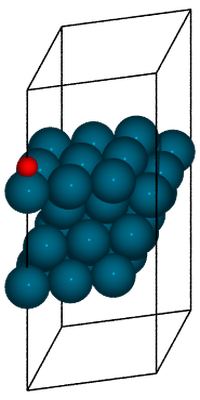

       Step     Time          Energy          fmax
LBFGS:    0 06:33:15     -182.724943       15.996336
LBFGS:    1 06:33:15     -185.101618        3.658140
LBFGS:    2 06:33:15     -185.399953        3.125055
LBFGS:    3 06:33:15     -185.830059        4.324576
LBFGS:    4 06:33:16     -186.065281        1.486654
LBFGS:    5 06:33:16     -186.154006        1.534737
LBFGS:    6 06:33:16     -186.183752        0.756340
LBFGS:    7 06:33:16     -186.216309        0.521000
LBFGS:    8 06:33:16     -186.267515        1.117358
LBFGS:    9 06:33:16     -186.303259        0.829272
LBFGS:   10 06:33:16     -186.324989        0.471948
LBFGS:   11 06:33:17     -186.342663        0.341791
LBFGS:   12 06:33:17     -186.369434        0.445932
LBFGS:   13 06:33:17     -186.386982        0.560154
LBFGS:   14 06:33:17     -186.401124        0.527080
LBFGS:   15 06:33:17     -186.411669        0.291650
LBFGS:   16 06:33:17     -186.418166        0.218306
LBFGS:   17 06:33:17     -186.421992        0.28

Total Progress:  25%|██▌       | 5/20 [01:28<03:50, 15.34s/it]

LBFGS:   44 06:33:21     -186.489516        0.070023
LBFGS:   45 06:33:21     -186.489749        0.038109


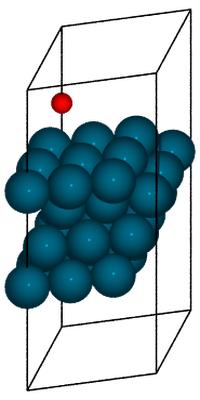

       Step     Time          Energy          fmax
LBFGS:    0 06:33:22     -182.724943       15.996336
LBFGS:    1 06:33:23     -185.101618        3.658140
LBFGS:    2 06:33:23     -185.399953        3.125055
LBFGS:    3 06:33:23     -185.830059        4.324576
LBFGS:    4 06:33:23     -186.065281        1.486654
LBFGS:    5 06:33:23     -186.154006        1.534737
LBFGS:    6 06:33:23     -186.183752        0.756340
LBFGS:    7 06:33:23     -186.216309        0.521000
LBFGS:    8 06:33:24     -186.267515        1.117358
LBFGS:    9 06:33:24     -186.303259        0.829272
LBFGS:   10 06:33:24     -186.324989        0.471948
LBFGS:   11 06:33:24     -186.342663        0.341791
LBFGS:   12 06:33:24     -186.369434        0.445932
LBFGS:   13 06:33:24     -186.386982        0.560154
LBFGS:   14 06:33:24     -186.401124        0.527080
LBFGS:   15 06:33:25     -186.411669        0.291650
LBFGS:   16 06:33:25     -186.418166        0.218306
LBFGS:   17 06:33:25     -186.421992        0.28

Total Progress:  30%|███       | 6/20 [01:35<02:57, 12.67s/it]

LBFGS:   44 06:33:29     -186.489516        0.070023
LBFGS:   45 06:33:29     -186.489749        0.038109


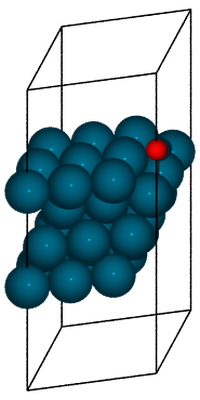

       Step     Time          Energy          fmax
LBFGS:    0 06:33:30     -182.724943       15.996336
LBFGS:    1 06:33:30     -185.101618        3.658140
LBFGS:    2 06:33:30     -185.399953        3.125055
LBFGS:    3 06:33:30     -185.830059        4.324576
LBFGS:    4 06:33:31     -186.065281        1.486654
LBFGS:    5 06:33:31     -186.154006        1.534737
LBFGS:    6 06:33:31     -186.183752        0.756340
LBFGS:    7 06:33:31     -186.216309        0.521000
LBFGS:    8 06:33:31     -186.267515        1.117358
LBFGS:    9 06:33:31     -186.303259        0.829272
LBFGS:   10 06:33:31     -186.324989        0.471948
LBFGS:   11 06:33:32     -186.342663        0.341791
LBFGS:   12 06:33:32     -186.369434        0.445932
LBFGS:   13 06:33:32     -186.386982        0.560154
LBFGS:   14 06:33:32     -186.401124        0.527080
LBFGS:   15 06:33:32     -186.411669        0.291650
LBFGS:   16 06:33:32     -186.418166        0.218306
LBFGS:   17 06:33:32     -186.421992        0.28

Total Progress:  35%|███▌      | 7/20 [01:43<02:22, 10.98s/it]

LBFGS:   44 06:33:36     -186.489516        0.070023
LBFGS:   45 06:33:36     -186.489749        0.038109


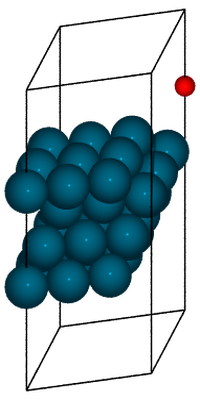

       Step     Time          Energy          fmax
LBFGS:    0 06:33:37     -182.724943       15.996336
LBFGS:    1 06:33:38     -185.101618        3.658140
LBFGS:    2 06:33:38     -185.399953        3.125055
LBFGS:    3 06:33:38     -185.830059        4.324576
LBFGS:    4 06:33:38     -186.065281        1.486654
LBFGS:    5 06:33:38     -186.154006        1.534737
LBFGS:    6 06:33:38     -186.183752        0.756340
LBFGS:    7 06:33:38     -186.216309        0.521000
LBFGS:    8 06:33:39     -186.267515        1.117358
LBFGS:    9 06:33:39     -186.303259        0.829272
LBFGS:   10 06:33:39     -186.324989        0.471948
LBFGS:   11 06:33:39     -186.342663        0.341791
LBFGS:   12 06:33:39     -186.369434        0.445932
LBFGS:   13 06:33:39     -186.386982        0.560154
LBFGS:   14 06:33:39     -186.401124        0.527080
LBFGS:   15 06:33:40     -186.411669        0.291650
LBFGS:   16 06:33:40     -186.418166        0.218306
LBFGS:   17 06:33:40     -186.421992        0.28

Total Progress:  40%|████      | 8/20 [01:51<01:58,  9.90s/it]

LBFGS:   44 06:33:44     -186.489516        0.070023
LBFGS:   45 06:33:44     -186.489749        0.038109


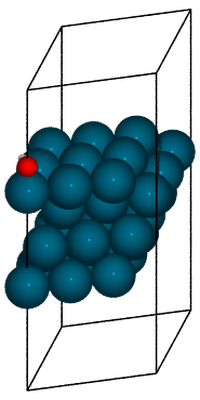

       Step     Time          Energy          fmax
LBFGS:    0 06:33:45     -185.861608        5.179033
LBFGS:    1 06:33:45     -186.288891        1.165325
LBFGS:    2 06:33:45     -186.320332        0.408347
LBFGS:    3 06:33:46     -186.329422        0.338956
LBFGS:    4 06:33:46     -186.337717        0.412851
LBFGS:    5 06:33:46     -186.348042        0.540513
LBFGS:    6 06:33:46     -186.359201        0.524692
LBFGS:    7 06:33:46     -186.369567        0.350039
LBFGS:    8 06:33:46     -186.375822        0.208475
LBFGS:    9 06:33:46     -186.380442        0.264166
LBFGS:   10 06:33:46     -186.387381        0.370951
LBFGS:   11 06:33:47     -186.395519        0.331721
LBFGS:   12 06:33:47     -186.400689        0.165649
LBFGS:   13 06:33:47     -186.403587        0.119519
LBFGS:   14 06:33:47     -186.406653        0.179469
LBFGS:   15 06:33:47     -186.410438        0.275593
LBFGS:   16 06:33:47     -186.415036        0.306499
LBFGS:   17 06:33:47     -186.419280        0.23

Total Progress:  45%|████▌     | 9/20 [01:57<01:36,  8.80s/it]

LBFGS:   36 06:33:50     -186.487435        0.097649
LBFGS:   37 06:33:50     -186.488110        0.040507


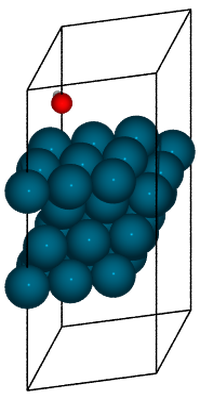

       Step     Time          Energy          fmax
LBFGS:    0 06:33:51     -185.861608        5.179033
LBFGS:    1 06:33:52     -186.288891        1.165325
LBFGS:    2 06:33:52     -186.320332        0.408347
LBFGS:    3 06:33:52     -186.329422        0.338956
LBFGS:    4 06:33:52     -186.337717        0.412851
LBFGS:    5 06:33:52     -186.348042        0.540513
LBFGS:    6 06:33:52     -186.359201        0.524692
LBFGS:    7 06:33:52     -186.369567        0.350039
LBFGS:    8 06:33:53     -186.375822        0.208475
LBFGS:    9 06:33:53     -186.380442        0.264166
LBFGS:   10 06:33:53     -186.387381        0.370951
LBFGS:   11 06:33:53     -186.395519        0.331721
LBFGS:   12 06:33:53     -186.400689        0.165649
LBFGS:   13 06:33:53     -186.403587        0.119519
LBFGS:   14 06:33:53     -186.406653        0.179469
LBFGS:   15 06:33:54     -186.410438        0.275593
LBFGS:   16 06:33:54     -186.415036        0.306499
LBFGS:   17 06:33:54     -186.419280        0.23

Total Progress:  50%|█████     | 10/20 [02:03<01:20,  8.07s/it]

LBFGS:   36 06:33:56     -186.487435        0.097649
LBFGS:   37 06:33:57     -186.488110        0.040507


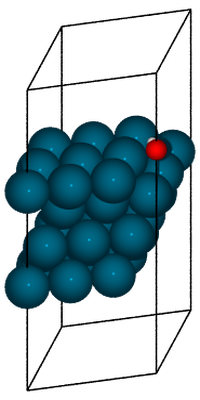

       Step     Time          Energy          fmax
LBFGS:    0 06:33:58     -185.861608        5.179033
LBFGS:    1 06:33:58     -186.288891        1.165325
LBFGS:    2 06:33:58     -186.320332        0.408347
LBFGS:    3 06:33:58     -186.329422        0.338956
LBFGS:    4 06:33:58     -186.337717        0.412851
LBFGS:    5 06:33:59     -186.348042        0.540513
LBFGS:    6 06:33:59     -186.359201        0.524692
LBFGS:    7 06:33:59     -186.369567        0.350039
LBFGS:    8 06:33:59     -186.375822        0.208475
LBFGS:    9 06:33:59     -186.380442        0.264166
LBFGS:   10 06:33:59     -186.387381        0.370951
LBFGS:   11 06:33:59     -186.395519        0.331721
LBFGS:   12 06:34:00     -186.400689        0.165649
LBFGS:   13 06:34:00     -186.403587        0.119519
LBFGS:   14 06:34:00     -186.406653        0.179469
LBFGS:   15 06:34:00     -186.410438        0.275593
LBFGS:   16 06:34:00     -186.415036        0.306499
LBFGS:   17 06:34:00     -186.419280        0.23

Total Progress:  55%|█████▌    | 11/20 [02:10<01:07,  7.55s/it]

LBFGS:   36 06:34:03     -186.487435        0.097649
LBFGS:   37 06:34:03     -186.488110        0.040507


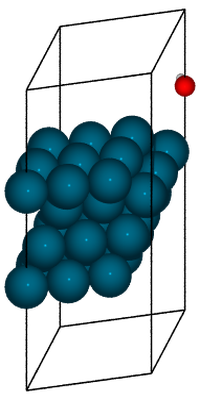

       Step     Time          Energy          fmax
LBFGS:    0 06:34:04     -185.861608        5.179033
LBFGS:    1 06:34:04     -186.288891        1.165325
LBFGS:    2 06:34:05     -186.320332        0.408347
LBFGS:    3 06:34:05     -186.329422        0.338956
LBFGS:    4 06:34:05     -186.337717        0.412851
LBFGS:    5 06:34:05     -186.348042        0.540513
LBFGS:    6 06:34:05     -186.359201        0.524692
LBFGS:    7 06:34:05     -186.369567        0.350039
LBFGS:    8 06:34:05     -186.375822        0.208475
LBFGS:    9 06:34:06     -186.380442        0.264166
LBFGS:   10 06:34:06     -186.387381        0.370951
LBFGS:   11 06:34:06     -186.395519        0.331721
LBFGS:   12 06:34:06     -186.400689        0.165649
LBFGS:   13 06:34:06     -186.403587        0.119519
LBFGS:   14 06:34:06     -186.406653        0.179469
LBFGS:   15 06:34:06     -186.410438        0.275593
LBFGS:   16 06:34:07     -186.415036        0.306499
LBFGS:   17 06:34:07     -186.419280        0.23

Total Progress:  60%|██████    | 12/20 [02:16<00:57,  7.24s/it]

LBFGS:   36 06:34:09     -186.487435        0.097649
LBFGS:   37 06:34:10     -186.488110        0.040507


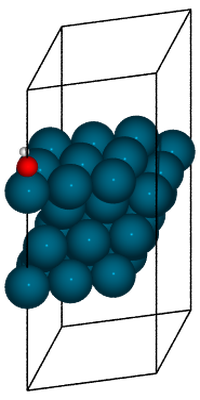

       Step     Time          Energy          fmax
LBFGS:    0 06:34:11     -185.404368        6.237303
LBFGS:    1 06:34:11     -185.892435        3.200403
LBFGS:    2 06:34:11     -186.065998        1.138606
LBFGS:    3 06:34:11     -186.103642        0.958454
LBFGS:    4 06:34:11     -186.229171        0.997331
LBFGS:    5 06:34:12     -186.269607        0.748683
LBFGS:    6 06:34:12     -186.300945        0.415601
LBFGS:    7 06:34:12     -186.310497        0.266360
LBFGS:    8 06:34:12     -186.317978        0.328586
LBFGS:    9 06:34:12     -186.324847        0.325007
LBFGS:   10 06:34:12     -186.328861        0.240752
LBFGS:   11 06:34:12     -186.330666        0.196187
LBFGS:   12 06:34:12     -186.332818        0.107664
LBFGS:   13 06:34:13     -186.334043        0.105561
LBFGS:   14 06:34:13     -186.335276        0.151332
LBFGS:   15 06:34:13     -186.336748        0.188482
LBFGS:   16 06:34:13     -186.338512        0.179990
LBFGS:   17 06:34:13     -186.340218        0.12

Total Progress:  65%|██████▌   | 13/20 [02:25<00:53,  7.71s/it]

LBFGS:   54 06:34:18     -186.488042        0.039652


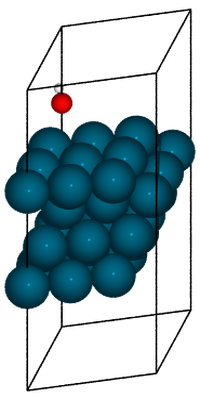

       Step     Time          Energy          fmax
LBFGS:    0 06:34:20     -185.404368        6.237303
LBFGS:    1 06:34:20     -185.892435        3.200403
LBFGS:    2 06:34:20     -186.065998        1.138606
LBFGS:    3 06:34:20     -186.103642        0.958454
LBFGS:    4 06:34:20     -186.229171        0.997331
LBFGS:    5 06:34:21     -186.269607        0.748683
LBFGS:    6 06:34:21     -186.300945        0.415601
LBFGS:    7 06:34:21     -186.310497        0.266360
LBFGS:    8 06:34:21     -186.317978        0.328586
LBFGS:    9 06:34:21     -186.324847        0.325007
LBFGS:   10 06:34:21     -186.328861        0.240752
LBFGS:   11 06:34:21     -186.330666        0.196187
LBFGS:   12 06:34:22     -186.332818        0.107664
LBFGS:   13 06:34:22     -186.334043        0.105561
LBFGS:   14 06:34:22     -186.335276        0.151332
LBFGS:   15 06:34:22     -186.336748        0.188482
LBFGS:   16 06:34:22     -186.338512        0.179990
LBFGS:   17 06:34:22     -186.340218        0.12

Total Progress:  70%|███████   | 14/20 [02:34<00:48,  8.11s/it]

LBFGS:   54 06:34:27     -186.488042        0.039652


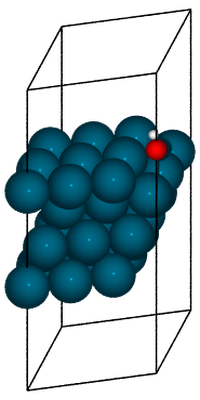

       Step     Time          Energy          fmax
LBFGS:    0 06:34:29     -185.404368        6.237303
LBFGS:    1 06:34:29     -185.892435        3.200403
LBFGS:    2 06:34:29     -186.065998        1.138606
LBFGS:    3 06:34:29     -186.103642        0.958454
LBFGS:    4 06:34:29     -186.229171        0.997331
LBFGS:    5 06:34:29     -186.269607        0.748683
LBFGS:    6 06:34:29     -186.300945        0.415601
LBFGS:    7 06:34:30     -186.310497        0.266360
LBFGS:    8 06:34:30     -186.317978        0.328586
LBFGS:    9 06:34:30     -186.324847        0.325007
LBFGS:   10 06:34:30     -186.328861        0.240752
LBFGS:   11 06:34:30     -186.330666        0.196187
LBFGS:   12 06:34:30     -186.332818        0.107664
LBFGS:   13 06:34:30     -186.334043        0.105561
LBFGS:   14 06:34:31     -186.335276        0.151332
LBFGS:   15 06:34:31     -186.336748        0.188482
LBFGS:   16 06:34:31     -186.338512        0.179990
LBFGS:   17 06:34:31     -186.340218        0.12

Total Progress:  75%|███████▌  | 15/20 [02:43<00:41,  8.34s/it]

LBFGS:   54 06:34:36     -186.488042        0.039652


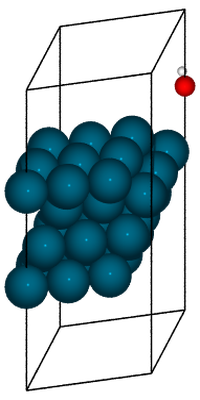

       Step     Time          Energy          fmax
LBFGS:    0 06:34:37     -185.404368        6.237303
LBFGS:    1 06:34:38     -185.892435        3.200403
LBFGS:    2 06:34:38     -186.065998        1.138606
LBFGS:    3 06:34:38     -186.103642        0.958454
LBFGS:    4 06:34:38     -186.229171        0.997331
LBFGS:    5 06:34:38     -186.269607        0.748683
LBFGS:    6 06:34:38     -186.300945        0.415601
LBFGS:    7 06:34:38     -186.310497        0.266360
LBFGS:    8 06:34:39     -186.317978        0.328586
LBFGS:    9 06:34:39     -186.324847        0.325007
LBFGS:   10 06:34:39     -186.328861        0.240752
LBFGS:   11 06:34:39     -186.330666        0.196187
LBFGS:   12 06:34:39     -186.332818        0.107664
LBFGS:   13 06:34:39     -186.334043        0.105561
LBFGS:   14 06:34:39     -186.335276        0.151332
LBFGS:   15 06:34:40     -186.336748        0.188482
LBFGS:   16 06:34:40     -186.338512        0.179990
LBFGS:   17 06:34:40     -186.340218        0.12

Total Progress:  80%|████████  | 16/20 [02:52<00:33,  8.46s/it]

LBFGS:   54 06:34:45     -186.488042        0.039652


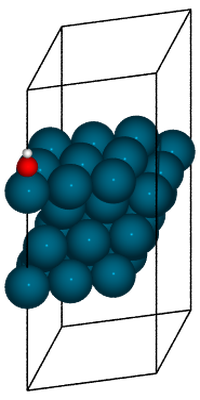

       Step     Time          Energy          fmax
LBFGS:    0 06:34:46     -184.927219        5.811489
LBFGS:    1 06:34:47     -185.205813        5.763703
LBFGS:    2 06:34:47     -185.425840        0.751592
LBFGS:    3 06:34:47     -185.443521        0.478539
LBFGS:    4 06:34:47     -185.457896        0.438910
LBFGS:    5 06:34:47     -185.471765        0.601533
LBFGS:    6 06:34:47     -185.487078        0.609378
LBFGS:    7 06:34:47     -185.500491        0.468712
LBFGS:    8 06:34:48     -185.513551        0.287208
LBFGS:    9 06:34:48     -185.524564        0.293992
LBFGS:   10 06:34:48     -185.533759        0.262686
LBFGS:   11 06:34:48     -185.543615        0.303315
LBFGS:   12 06:34:48     -185.549892        0.190998
LBFGS:   13 06:34:48     -185.552187        0.097552
LBFGS:   14 06:34:48     -185.553355        0.089249
LBFGS:   15 06:34:49     -185.554682        0.140260
LBFGS:   16 06:34:49     -185.556154        0.135695
LBFGS:   17 06:34:49     -185.557215        0.08

Total Progress:  85%|████████▌ | 17/20 [02:56<00:21,  7.28s/it]

LBFGS:   22 06:34:50     -185.559162        0.028852


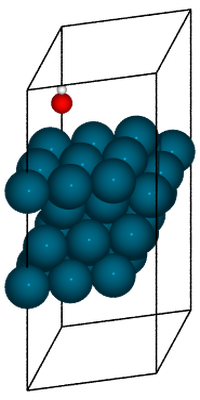

       Step     Time          Energy          fmax
LBFGS:    0 06:34:51     -184.927219        5.811489
LBFGS:    1 06:34:51     -185.205813        5.763703
LBFGS:    2 06:34:51     -185.425840        0.751592
LBFGS:    3 06:34:51     -185.443521        0.478539
LBFGS:    4 06:34:51     -185.457896        0.438910
LBFGS:    5 06:34:51     -185.471765        0.601533
LBFGS:    6 06:34:52     -185.487078        0.609378
LBFGS:    7 06:34:52     -185.500491        0.468712
LBFGS:    8 06:34:52     -185.513551        0.287208
LBFGS:    9 06:34:52     -185.524564        0.293992
LBFGS:   10 06:34:52     -185.533759        0.262686
LBFGS:   11 06:34:52     -185.543615        0.303315
LBFGS:   12 06:34:52     -185.549892        0.190998
LBFGS:   13 06:34:53     -185.552187        0.097552
LBFGS:   14 06:34:53     -185.553355        0.089249
LBFGS:   15 06:34:53     -185.554682        0.140260
LBFGS:   16 06:34:53     -185.556154        0.135695
LBFGS:   17 06:34:53     -185.557215        0.08

Total Progress:  90%|█████████ | 18/20 [03:01<00:12,  6.40s/it]

LBFGS:   22 06:34:54     -185.559162        0.028852


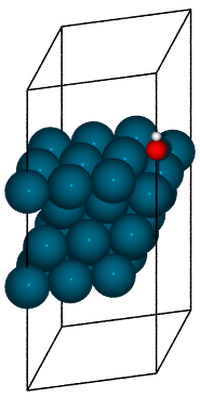

       Step     Time          Energy          fmax
LBFGS:    0 06:34:55     -184.927219        5.811489
LBFGS:    1 06:34:55     -185.205813        5.763703
LBFGS:    2 06:34:55     -185.425840        0.751592
LBFGS:    3 06:34:56     -185.443521        0.478539
LBFGS:    4 06:34:56     -185.457896        0.438910
LBFGS:    5 06:34:56     -185.471765        0.601533
LBFGS:    6 06:34:56     -185.487078        0.609378
LBFGS:    7 06:34:56     -185.500491        0.468712
LBFGS:    8 06:34:56     -185.513551        0.287208
LBFGS:    9 06:34:56     -185.524564        0.293992
LBFGS:   10 06:34:57     -185.533759        0.262686
LBFGS:   11 06:34:57     -185.543615        0.303315
LBFGS:   12 06:34:57     -185.549892        0.190998
LBFGS:   13 06:34:57     -185.552187        0.097552
LBFGS:   14 06:34:57     -185.553355        0.089249
LBFGS:   15 06:34:57     -185.554682        0.140260
LBFGS:   16 06:34:57     -185.556154        0.135695
LBFGS:   17 06:34:58     -185.557215        0.08

Total Progress:  95%|█████████▌| 19/20 [03:05<00:05,  5.79s/it]

LBFGS:   22 06:34:58     -185.559162        0.028852


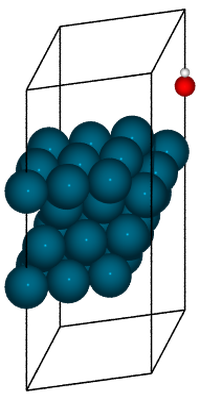

       Step     Time          Energy          fmax
LBFGS:    0 06:35:00     -184.927219        5.811489
LBFGS:    1 06:35:00     -185.205813        5.763703
LBFGS:    2 06:35:00     -185.425840        0.751592
LBFGS:    3 06:35:00     -185.443521        0.478539
LBFGS:    4 06:35:00     -185.457896        0.438910
LBFGS:    5 06:35:00     -185.471765        0.601533
LBFGS:    6 06:35:00     -185.487078        0.609378
LBFGS:    7 06:35:01     -185.500491        0.468712
LBFGS:    8 06:35:01     -185.513551        0.287208
LBFGS:    9 06:35:01     -185.524564        0.293992
LBFGS:   10 06:35:01     -185.533759        0.262686
LBFGS:   11 06:35:01     -185.543615        0.303315
LBFGS:   12 06:35:01     -185.549892        0.190998
LBFGS:   13 06:35:01     -185.552187        0.097552
LBFGS:   14 06:35:02     -185.553355        0.089249
LBFGS:   15 06:35:02     -185.554682        0.140260
LBFGS:   16 06:35:02     -185.556154        0.135695
LBFGS:   17 06:35:02     -185.557215        0.08

Total Progress: 100%|██████████| 20/20 [03:09<00:00,  9.50s/it]

LBFGS:   22 06:35:03     -185.559162        0.028852

가장 안정한 흡착 에너지: -43.4732 eV
총 20개 configuration 탐색 완료


In [44]:
from tqdm import tqdm
from ase.build import bulk, surface
from ase.build import add_adsorbate
from ase.build import molecule
import copy

size = 3
vac = 7.5
miller_index = (1,0,0)  # Step 2에서 가장 안정했던 facet으로 교체

N_bulk_layer = 2
N_surface_layer = 2

# ── Slab 생성 ──────────────────────────────────────────
bulk_pd = bulk('Pd', 'fcc')
surf = surface(bulk_pd, miller_index, layers=N_bulk_layer + N_surface_layer, vacuum=vac)
surf = surf.repeat([size, size, 1])

# 하단 N_bulk_layer 레이어 고정
z_positions = surf.positions[:, 2]
z_sorted = np.sort(np.unique(z_positions.round(2)))
z_fixed_threshold = z_sorted[N_bulk_layer - 1]  # 고정할 z 경계

fixed_indices = [i for i, atom in enumerate(surf)
                 if round(atom.position[2], 2) <= round(z_fixed_threshold, 2)]
surf.set_constraint(FixAtoms(indices=fixed_indices))

# Surface energy 계산
surf_energy = energy_cal(surf, mace_calc, lattice_relax=False, relax_atoms=True)
N_surf_atoms = len(surf)
A = np.linalg.norm(np.cross(surf.cell[0], surf.cell[1]))
surf_energy_Jm2 = (surf_energy - N_surf_atoms * E_bulk_per_atom_fr) / (2 * A) * 16.02
print(f"Surface energy: {surf_energy_Jm2:.4f} J/m²")

# ── OH reference energy ────────────────────────────────
oh_ref = molecule('OH')
oh_ref.calc = mace_calc
E_OH = oh_ref.get_potential_energy()

# ── Adsorption Configuration Enumeration ──────────────
surf_z_max = np.max(surf.positions[:, -1])
lattice_a, lattice_b, _ = surf.cell.array[0], surf.cell.array[1], surf.cell.array[2]

a_num = 2
b_num = 2
rot_num = 5
a_range = np.linspace(0, 1, a_num)
b_range = np.linspace(0, 1, b_num)
rot_range = np.linspace(0, 180, rot_num)

total_num = a_num * b_num * rot_num

surf_with_adsorbate_list = []
adsorption_energy_list = []

with tqdm(total=total_num, desc="Total Progress") as pbar:
    for rot in rot_range:
        oh_atoms = molecule('OH')
        O_index = [atom.index for atom in oh_atoms if atom.symbol == 'O'][0]
        O_position = oh_atoms.positions[O_index]
        oh_atoms.rotate(v='x', a=rot, center=O_position)

        # ── TO-DO: adsorption site enumeration ──────────
        for idx_a, a in enumerate(a_range):
            for idx_b, b in enumerate(b_range):

                # OH를 표면 위 각 (a,b) 위치에 배치
                oh_placed = oh_atoms.copy()
                xy_offset = lattice_a * a + lattice_b * b
                oh_placed.translate([
                    xy_offset[0] - oh_placed.positions[O_index][0],
                    xy_offset[1] - oh_placed.positions[O_index][1],
                    surf_z_max + 1.8 - oh_placed.positions[O_index][2]
                ])

                surf_with_adsorbate = copy.deepcopy(surf) + oh_placed
                visual(surf_with_adsorbate)

                # ── 에너지 계산 ──────────────────────────
                optimized_energy = energy_cal(
                    surf_with_adsorbate, mace_calc,
                    lattice_relax=False, relax_atoms=True
                )

                surf_with_adsorbate_list.append(surf_with_adsorbate)

                # ── 흡착 에너지 계산 ─────────────────────
                # E_ads = E(slab+OH) - E(slab) - E(OH)
                adsorption_energy = optimized_energy - surf_energy - E_OH
                adsorption_energy_list.append(adsorption_energy)

                pbar.update(1)

# ── 결과 출력 ──────────────────────────────────────────
best_idx = np.argmin(adsorption_energy_list)
print(f"\n가장 안정한 흡착 에너지: {adsorption_energy_list[best_idx]:.4f} eV")
print(f"총 {len(adsorption_energy_list)}개 configuration 탐색 완료")

### STEP 5: Final Optimized Adsorption Energy

Optimized adsorption energy : -43.47322028189406 eV


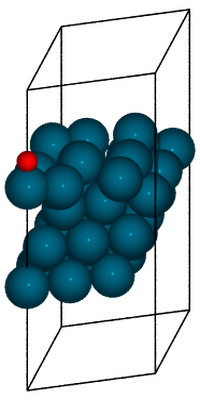

In [45]:
min_ads_idx = np.argmin(np.array(adsorption_energy_list))

print(f"Optimized adsorption energy : {adsorption_energy_list[min_ads_idx]} eV")
visual(surf_with_adsorbate_list[min_ads_idx])